In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import proplot as pplt
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyarrow.feather as feather
from scipy.stats import gaussian_kde


import pandas as pd
import geopandas as gpd
# attrs.set_index('gauge_id', inplace=True)

import io
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import proplot as pplt
import matplotlib as mpl
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
import requests
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import xarray as xr

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas import read_feather



# ET Compariosn:

Found feather files for 505 basins in BUDYKO_DA
Found feather files for 505 basins in Budyko MODEL
Found feather files for 505 basins in BASE MODEL
Shapes after alignment:
SFET: (178, 497)
ET_ke: (178, 497)
ET_B: (178, 497)
ET_ass: (178, 497)
         scenario       KGE
gauge_id                   
01013500    ET_ke  0.421628
01013500     ET_B  0.456587
01013500   ET_ass  0.421604
01022500    ET_ke  0.677404
01022500     ET_B  0.585970


C:\Users\hdagne1\AppData\Local\Temp\ipykernel_32784\782622495.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


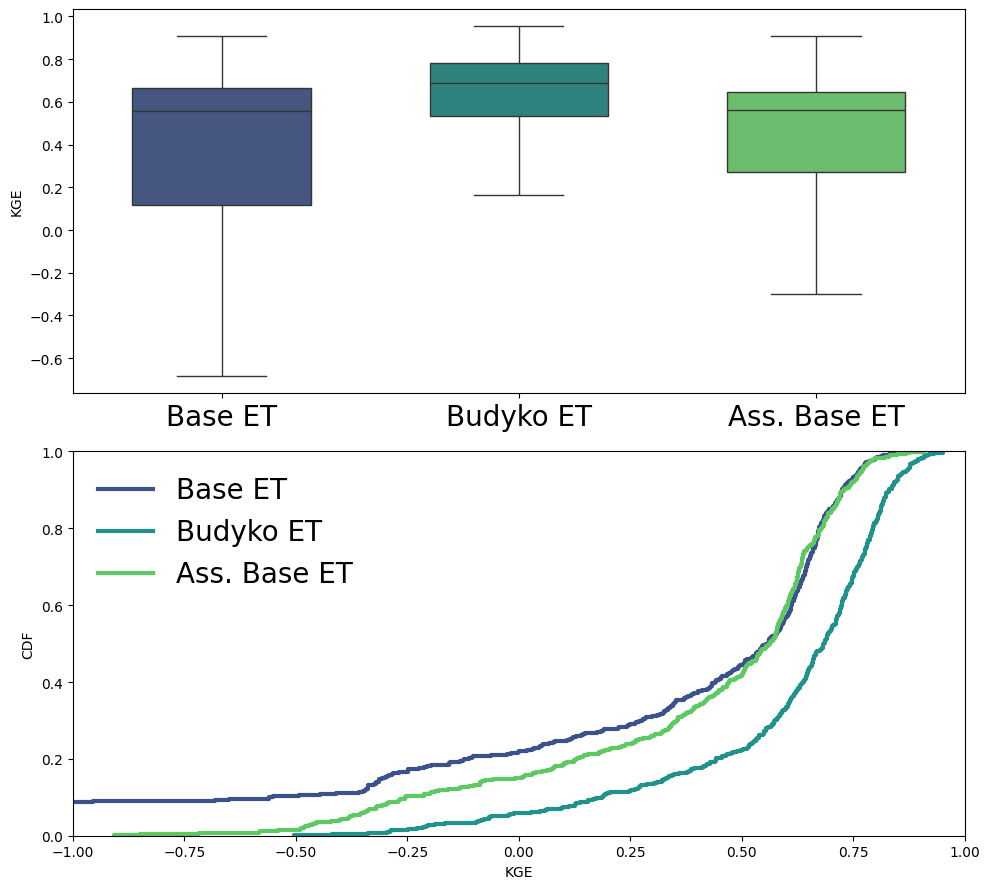

In [20]:
# ============================================================
# ET Performance vs SFET
# 1) KGE boxplots + ECDF
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# KGE (2012) function
# ============================================================
def kge_2012(evaluation, simulation):
    """
    Kling-Gupta Efficiency (KGE 2012)
    evaluation: observed (SFET)
    simulation: model (ET_ke, ET_B, ET_ass)
    """
    e = np.asarray(evaluation, dtype=np.float64)
    s = np.asarray(simulation, dtype=np.float64)

    m = np.isfinite(e) & np.isfinite(s)
    e = e[m]
    s = s[m]

    if len(e) < 5:
        return np.nan

    # correlation
    r = np.corrcoef(e, s)[0, 1]
    if not np.isfinite(r):
        return np.nan

    # variability ratio
    alpha = np.std(s) / np.std(e) if np.std(e) != 0 else np.nan

    # bias ratio
    beta = np.mean(s) / np.mean(e) if np.mean(e) != 0 else np.nan

    if not (np.isfinite(alpha) and np.isfinite(beta)):
        return np.nan

    kge = 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    return kge


# ============================================================
# 1) Load SFET monthly
# ============================================================
SFET = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather")
SFET.set_index("time", inplace=True)
SFET.index = pd.to_datetime(SFET.index)

# monthly sum
SFET_monthly = SFET.resample("MS").sum()
SFET_monthly.index.name = "time"

# clean cols + remove duplicates
SFET_monthly.columns = SFET_monthly.columns.astype(str).str.strip()
SFET_monthly = SFET_monthly.loc[:, ~SFET_monthly.columns.duplicated()].copy()


# ============================================================
# 2) Load ET_ass from Feather files (BUDYKO_DA scenario)
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_DA"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_DA_*.feather"))
print(f"Found feather files for {len(files)} basins in BUDYKO_DA")

et_dict = {}

for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_DA_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df["time"] = pd.to_datetime(df["time"])

    df_et = df[["time", "ET_ass"]].copy().set_index("time").sort_index()
    et_dict[gauge_id] = df_et["ET_ass"]

ET_ass_all_basins = pd.DataFrame(et_dict).sort_index()
ET_ass_all_basins.index.name = "time"


# ============================================================
# 3) Load ET_B from Budyko MODEL feather files
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_MODEL"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_*.feather"))
print(f"Found feather files for {len(files)} basins in Budyko MODEL")


et_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df["time"] = pd.to_datetime(df["time"])

    df_et = df[["time", "ET_B"]].copy().set_index("time").sort_index()
    et_dict[gauge_id] = df_et["ET_B"]

ET_B_all_basins = pd.DataFrame(et_dict).sort_index()
ET_B_all_basins.index.name = "time"


# ============================================================
# 4) Load ET_ke from BASE MODEL feather files
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BASE_MODEL"
files = glob.glob(os.path.join(BASE_DIR, "results_BASE_*.feather"))
print(f"Found feather files for {len(files)} basins in BASE MODEL")

et_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BASE_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df["time"] = pd.to_datetime(df["time"])

    df_et = df[["time", "ET_ke"]].copy().set_index("time").sort_index()
    et_dict[gauge_id] = df_et["ET_ke"]

ET_ke_all_basins = pd.DataFrame(et_dict).sort_index()
ET_ke_all_basins.index.name = "time"


# ============================================================
# 5) Align time + basins
# ============================================================
# monthly resample model outputs too
ET_ke_monthly = ET_ke_all_basins.resample("MS").sum()
ET_B_monthly = ET_B_all_basins.resample("MS").sum()
ET_ass_monthly = ET_ass_all_basins.resample("MS").sum()

# clean columns
for df_ in [ET_ke_monthly, ET_B_monthly, ET_ass_monthly]:
    df_.columns = df_.columns.astype(str).str.strip()
    df_[:] = df_.astype(float)

# align time
indx = SFET_monthly.index
indx = indx.intersection(ET_ke_monthly.index).intersection(ET_B_monthly.index).intersection(ET_ass_monthly.index)

SFET_monthly = SFET_monthly.loc[indx].copy()
ET_ke_monthly = ET_ke_monthly.loc[indx].copy()
ET_B_monthly = ET_B_monthly.loc[indx].copy()
ET_ass_monthly = ET_ass_monthly.loc[indx].copy()

# common basins
common_cols = (
    SFET_monthly.columns
    .intersection(ET_ke_monthly.columns)
    .intersection(ET_B_monthly.columns)
    .intersection(ET_ass_monthly.columns)
)

SFET_monthly = SFET_monthly.loc[:, common_cols].copy()
ET_ke_monthly = ET_ke_monthly.loc[:, common_cols].copy()
ET_B_monthly = ET_B_monthly.loc[:, common_cols].copy()
ET_ass_monthly = ET_ass_monthly.loc[:, common_cols].copy()

print("Shapes after alignment:")
print("SFET:", SFET_monthly.shape)
print("ET_ke:", ET_ke_monthly.shape)
print("ET_B:", ET_B_monthly.shape)
print("ET_ass:", ET_ass_monthly.shape)


# ============================================================
# 6) Compute KGE basin-by-basin
# ============================================================
rows = []
for g in common_cols:
    obs = SFET_monthly[g].values

    rows.append({"gauge_id": g, "scenario": "ET_ke",  "KGE": kge_2012(obs, ET_ke_monthly[g].values)})
    rows.append({"gauge_id": g, "scenario": "ET_B",   "KGE": kge_2012(obs, ET_B_monthly[g].values)})
    rows.append({"gauge_id": g, "scenario": "ET_ass", "KGE": kge_2012(obs, ET_ass_monthly[g].values)})

perform = pd.DataFrame(rows).set_index("gauge_id")
print(perform.head())


# ============================================================
# 7) Boxplot + ECDF (your style)
# ============================================================
label_map = {
    "ET_ke": "Base ET",
    "ET_B": "Budyko ET",
    "ET_ass": "Ass. Base ET"
}

unique_scenarios = perform["scenario"].unique()
metrics = ["KGE"]

palette_list = sns.color_palette("viridis", len(unique_scenarios))
labels = [label_map.get(s, s) for s in unique_scenarios]

fig, axs = plt.subplots(2, 1, figsize=(10, 9))

# --- Boxplot ---
sns.boxplot(
    x="scenario",
    y="KGE",
    data=perform,
    order=unique_scenarios,
    palette=palette_list,
    ax=axs[0],
    showfliers=False,
    width=0.6
)
axs[0].set(xlabel="", ylabel="KGE")
axs[0].set_xticks(range(len(unique_scenarios)))
axs[0].set_xticklabels(labels, rotation=0, ha="center", fontsize=20)

# --- ECDF ---
for s, color, lab in zip(unique_scenarios, palette_list, labels):
    subset = perform[perform["scenario"] == s]
    sns.ecdfplot(
        subset,
        x="KGE",
        color=color,
        label=lab,
        lw=3,
        ax=axs[1]
    )
axs[1].set(xlabel="KGE", ylabel="CDF", xlim=(-1, 1))

handles = [plt.Line2D([0], [0], color=c, lw=3) for c in palette_list]
axs[1].legend(handles, labels, frameon=False, fontsize=20, ncol=1)

plt.tight_layout()
plt.show()


# Q comparison:

Found 505 BASE MODEL feather files
Found 505 BUDYKO MODEL feather files
Found 505 BUDYKO_DA feather files

Final aligned shapes:
Q_USGS: (180, 50)
Q_base: (180, 50)
Q_budyko: (180, 50)
Q_ass: (180, 50)
Q_nldas: (180, 50)
Q_nwm: (180, 50)

Performance head:
          scenario       KGE
gauge_id                    
12115000    Q_base  0.479109
12115000  Q_budyko  0.477987
12115000     Q_ass  0.467625
12115000   Q_nldas  0.618687
12115000     Q_nwm -0.361419


C:\Users\hdagne1\AppData\Local\Temp\ipykernel_32784\1360861782.py:247: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


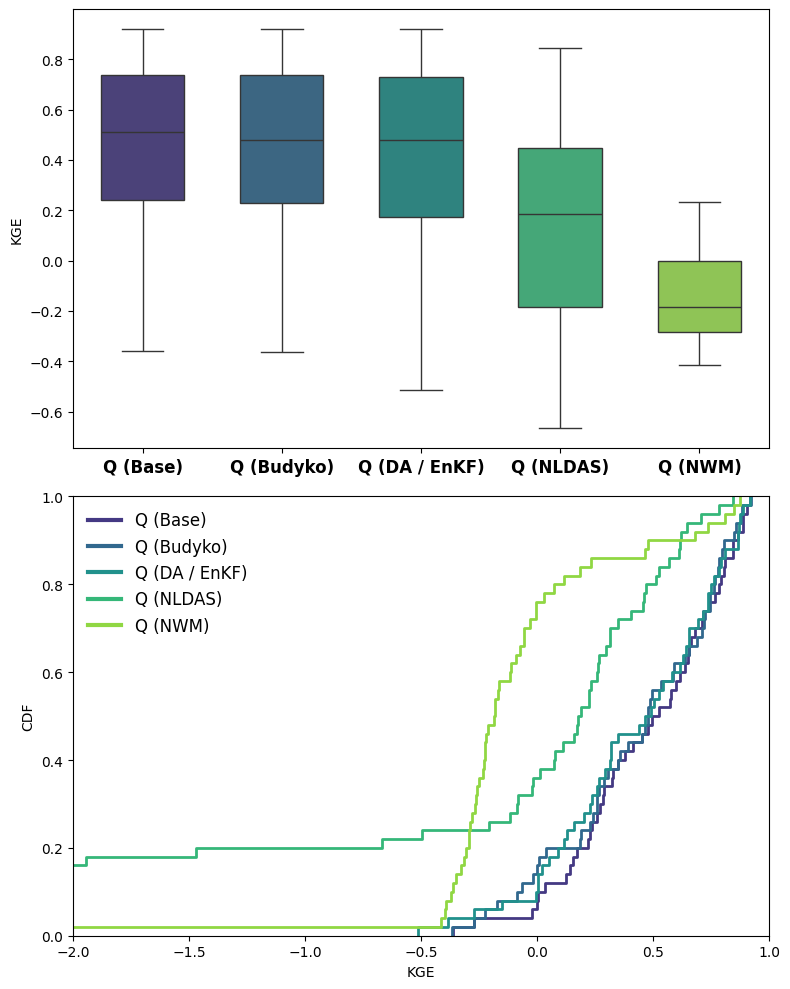

In [39]:
# ============================================================
# Q Performance vs USGS (ROBUST: time can be column or index)
# 1) Compute KGE basin-by-basin
# 2) Boxplot + ECDF (same format as before)
# 3) Mean time series plot
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# KGE (2012)
# ============================================================
def kge_2012(evaluation, simulation):
    e = np.asarray(evaluation, dtype=np.float64)
    s = np.asarray(simulation, dtype=np.float64)

    m = np.isfinite(e) & np.isfinite(s)
    e = e[m]
    s = s[m]

    if len(e) < 5:
        return np.nan

    r = np.corrcoef(e, s)[0, 1]
    if not np.isfinite(r):
        return np.nan

    alpha = np.std(s) / np.std(e) if np.std(e) != 0 else np.nan
    beta  = np.mean(s) / np.mean(e) if np.mean(e) != 0 else np.nan

    if not (np.isfinite(alpha) and np.isfinite(beta)):
        return np.nan

    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)


# ============================================================
# ROBUST time handler
# ============================================================
def ensure_time_index(df, time_col="time"):
    """
    Ensure df has DatetimeIndex.
    Works for:
      - df has a 'time' column
      - df already has time as index
    """
    df = df.copy()

    # Case 1: time is a column
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
        df = df.set_index(time_col)

    # Case 2: time is already index
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            try:
                df.index = pd.to_datetime(df.index)
            except Exception as e:
                raise ValueError(
                    "Could not convert index to datetime. "
                    "Your dataframe has no 'time' column and index is not datetime."
                ) from e

    return df.sort_index()


def monthly_sum(df):
    df = ensure_time_index(df)
    out = df.resample("MS").sum()
    out.index.name = "time"
    out.columns = out.columns.astype(str).str.strip()
    out = out.loc[:, ~out.columns.duplicated()].copy()
    return out


# ============================================================
# 1) Load Q_USGS (Observed)
# ============================================================
Q_USGS = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_USGS.feather")
Q_USGS_monthly = monthly_sum(Q_USGS)


# ============================================================
# 2) Load Q_nldas
# ============================================================
Q_nldas = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_nldas_mm_monthly.feather")
Q_nldas_monthly = monthly_sum(Q_nldas)


# ============================================================
# 3) Load Q_nwm
# ============================================================
NWM = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\NWM.feather")
Q_nwm_monthly = monthly_sum(NWM)


# ============================================================
# 4) Load Q_ke from BASE_MODEL results
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BASE_MODEL"
files = glob.glob(os.path.join(BASE_DIR, "results_BASE_*.feather"))
print(f"Found {len(files)} BASE MODEL feather files")

q_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BASE_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_base" not in df.columns:
        raise KeyError(f"Q_base not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_base"]

Q_base_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 5) Load Q_b from BUDYKO_MODEL results
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_MODEL"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_*.feather"))
print(f"Found {len(files)} BUDYKO MODEL feather files")

q_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_budyko" not in df.columns:
        raise KeyError(f"Q_budyko not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_budyko"]

Q_b_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 6) Load Q_ass from BUDYKO_DA feather results  ✅ UPDATED
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_DA"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_DA_*.feather"))
print(f"Found {len(files)} BUDYKO_DA feather files")

q_dict = {}

for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_DA_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_ens" not in df.columns:
        raise KeyError(f"Q_ens not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_ens"]

Q_ass_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 7) Align TIME + BASINS (all scenarios)
# ============================================================
dfs = {
    "Q_USGS": Q_USGS_monthly,
    "Q_base": Q_base_monthly,
    "Q_budyko": Q_b_monthly,
    "Q_ass": Q_ass_monthly,
    "Q_nldas": Q_nldas_monthly,
    "Q_nwm": Q_nwm_monthly,
}

# common time index
common_index = None
for name, df_ in dfs.items():
    common_index = df_.index if common_index is None else common_index.intersection(df_.index)

for name in dfs:
    dfs[name] = dfs[name].loc[common_index].copy()

# common columns
common_cols = None
for name, df_ in dfs.items():
    common_cols = df_.columns if common_cols is None else common_cols.intersection(df_.columns)

for name in dfs:
    dfs[name] = dfs[name].loc[:, common_cols].copy()

print("\nFinal aligned shapes:")
for name, df_ in dfs.items():
    print(f"{name}: {df_.shape}")


# ============================================================
# 8) Compute KGE against USGS
# ============================================================
rows = []
obs_df = dfs["Q_USGS"]

for g in common_cols:
    obs = obs_df[g].values

    for scenario in ["Q_base", "Q_budyko", "Q_ass", "Q_nldas", "Q_nwm"]:
        sim = dfs[scenario][g].values
        rows.append({
            "gauge_id": g,
            "scenario": scenario,
            "KGE": kge_2012(obs, sim)
        })

perform = pd.DataFrame(rows).set_index("gauge_id")
print("\nPerformance head:")
print(perform.head())


# ============================================================
# 9) Boxplot + ECDF (same format)
# ============================================================
label_map = {
    "Q_base": "Q (Base)",
    "Q_budyko": "Q (Budyko)",
    "Q_ass": "Q (DA / EnKF)",
    "Q_nldas": "Q (NLDAS)",
    "Q_nwm": "Q (NWM)"
}

unique_scenarios = perform["scenario"].unique()
palette_list = sns.color_palette("viridis", len(unique_scenarios))
labels = [label_map.get(s, s) for s in unique_scenarios]

fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# --- Boxplot ---
sns.boxplot(
    x="scenario",
    y="KGE",
    data=perform,
    order=unique_scenarios,
    palette=palette_list,
    ax=axs[0],
    showfliers=False,
    width=0.6
)
axs[0].set(xlabel="", ylabel="KGE")
axs[0].set_xticks(range(len(unique_scenarios)))
axs[0].set_xticklabels(labels, rotation=0, ha="center", fontweight='bold', fontsize=12)

# --- ECDF ---
for s, color, lab in zip(unique_scenarios, palette_list, labels):
    subset = perform[perform["scenario"] == s]
    sns.ecdfplot(
        subset,
        x="KGE",
        color=color,
        label=lab,
        lw=2,
        ax=axs[1]
    )

axs[1].set(xlabel="KGE", ylabel="CDF", xlim=(-2, 1))
handles = [plt.Line2D([0], [0], color=c, lw=3) for c in palette_list]
axs[1].legend(handles, labels, frameon=False, fontsize=12, ncol=1)

plt.tight_layout()
plt.show()


# Calibrated Parameters:

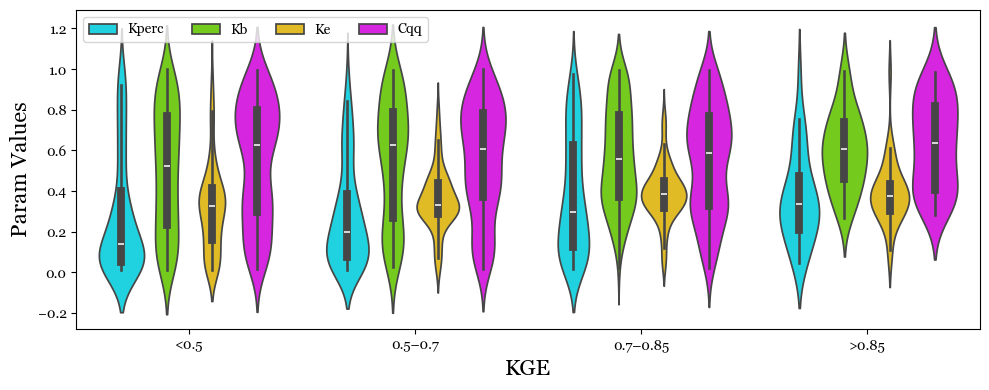

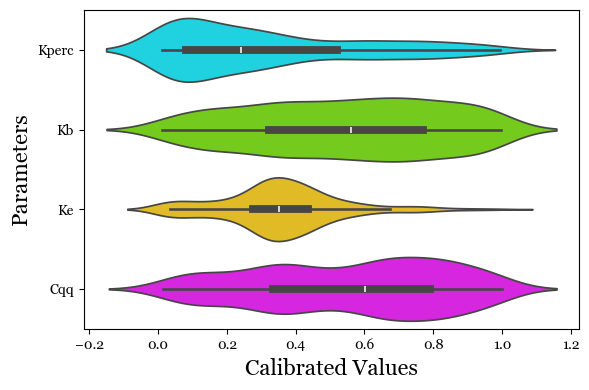

,Kperc,Kb,Ke,Cqq,Smax,fS0,fG0,Gmax_factor,S_init,G_init,KGE
count,505.000000,505.000000,505.000000,505.000000,505.00000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,0.317861,0.541184,0.355202,0.554250,270.34485,0.513911,0.491059,49.799475,142.411954,127.621331,0.564850
std,0.280145,0.278308,0.174978,0.275358,231.25499,0.277264,0.299054,28.071973,157.136144,144.781923,0.262514
min,0.010000,0.010000,0.011000,0.015000,0.05900,0.022000,0.007000,1.484000,0.022000,0.054000,-0.427000
25%,0.082000,0.321000,0.276000,0.334000,111.06000,0.290000,0.222000,26.730000,36.096000,29.673000,0.399000
50%,0.242000,0.560000,0.350000,0.602000,179.00000,0.511000,0.495000,49.800000,86.705000,81.464000,0.654000
75%,0.520000,0.771000,0.437000,0.792000,364.80000,0.752000,0.754000,71.750000,181.428000,166.637000,0.774000
max,0.993000,0.998000,0.988000,1.000000,993.50000,0.990000,0.989000,99.900000,879.374000,876.285000,0.942000


In [40]:
final_calibrated_params_with_KGE = pd.read_csv(r'F:\Github_repos\Bayesian_DA_Budyko_modeling\SCE_cal_params\final_calibrated_params_with_KGE.csv').set_index('Basin')

# plot 1:
plt.rcParams['font.family'] = 'Georgia'

df = final_calibrated_params_with_KGE.copy()

KGE_bins = [-1, 0.5, 0.7, 0.85, 1]
KGE_labels = ['<0.5', '0.5–0.7', '0.7–0.85', '>0.85']
df['KGE_class'] = pd.cut(df['KGE'], bins=KGE_bins, labels=KGE_labels)

params = ['Kperc', 'Kb', 'Ke', 'Cqq']
df_melted = df.melt(id_vars='KGE_class', value_vars=params,
                    var_name='Parameter', value_name='Value')


plt.figure(figsize=(10,4))
sns.violinplot(x='KGE_class', y='Value', hue='Parameter',
               data=df_melted, palette='gist_ncar', split=False, inner='box')
plt.xlabel('KGE', fontsize=16)
plt.ylabel('Param Values', fontsize=16)
plt.legend(loc='upper left', ncol=4, frameon=True)
plt.tight_layout()
plt.show()

# plot 2:

params = ['Kperc','Kb','Ke','Cqq']
df = final_calibrated_params_with_KGE.copy()
df['KGE_class'] = pd.cut(df['KGE'], bins=[-1,0.6,0.75,1], labels=['Poor','Good','Excellent'])

plt.figure(figsize=(6,4))
sns.violinplot(data=df[params], orient='h', palette='gist_ncar', inner='box')
plt.ylabel('Parameters', fontsize=16)
plt.xlabel('Calibrated Values', fontsize=16)
plt.tight_layout()
plt.show()
final_calibrated_params_with_KGE.describe()

# ET Scenarios under Budyko curves:

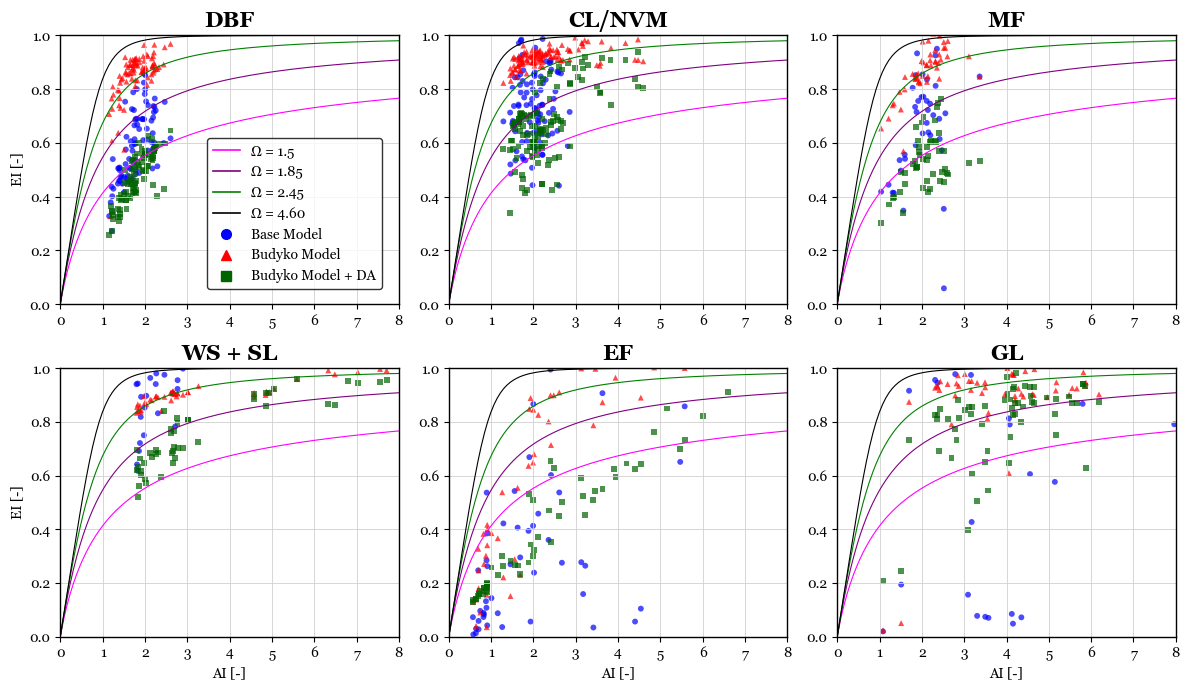

In [41]:
# ============================================================
# PYTHON VERSION OF YOUR R SCRIPT (Notebook-ready)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Global style (similar to theme_bw(base_family="Georgia"))
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "Georgia",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.color": "#d0d0d0",
    "grid.linewidth": 0.6,
    "xtick.color": "black",
    "ytick.color": "black",
})

# ============================================================
# LOAD DATA
# ============================================================
INPUT_CSV_PATH = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\attrs_SFET_geo_KGE.csv"

df = pd.read_csv(INPUT_CSV_PATH)
df["dom_land_cover_short"] = df["dom_land_cover_short"].astype(str)

# ============================================================
# BUDYKO FUNCTION (Fu)
# ============================================================
def Fu(AI, omega):
    # vector-safe implementation
    AI = np.asarray(AI, dtype=float)
    AIc = np.maximum(AI, 1e-6)
    return 1.0 + AIc - np.power(1.0 + np.power(AIc, omega), 1.0 / omega)

AI_range = np.concatenate([[0.0], np.linspace(0.01, 15, 199)])
dom_land_covers = ["DBF", "CL/NVM", "MF", "WS + SL", "EF", "GL"]

# ============================================================
# LEGEND ITEMS
# ============================================================
# Omega curves
omega_values = [1.5, 1.85, 2.45, 4.60]
omega_items  = ["Ω = 1.5", "Ω = 1.85", "Ω = 2.45", "Ω = 4.60"]
omega_colors = ["magenta", "purple", "green", "black"]

# Models
model_items  = ["Base Model", "Budyko Model", "Budyko Model + DA"]
model_colors = ["blue", "red", "darkgreen"]
model_markers = ["o", "^", "s"]   # matplotlib markers roughly like pch 19,17,15

# Unified legend order
legend_items  = omega_items + model_items

legend_color_map = {k: v for k, v in zip(omega_items, omega_colors)}
legend_color_map.update({k: v for k, v in zip(model_items, model_colors)})

legend_marker_map = {k: None for k in omega_items}
legend_marker_map.update({k: v for k, v in zip(model_items, model_markers)})

# ============================================================
# BUILD OMEGA CURVES (long format equivalent)
# ============================================================
curves = []
for w, label, col in zip(omega_values, omega_items, omega_colors):
    ei = Fu(AI_range, w)
    curves.append(pd.DataFrame({"AI": AI_range, "EI": ei, "item": label, "color": col}))
budyko_curves = pd.concat(curves, ignore_index=True)

# ============================================================
# BUILD PANELS (2x3) + legend in first subplot
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(12, 7))#, dpi=300)
axes = axes.ravel()

# model column mapping
model_map = {
    "Base Model": ("AI_ke", "EI_ke"),
    "Budyko Model": ("AI_B", "EI_B"),
    "Budyko Model + DA": ("AI_ass", "EI_ass"),
}

for i, lc in enumerate(dom_land_covers):
    ax = axes[i]

    filtered = df[df["dom_land_cover_short"] == lc].copy()

    # -----------------------------
    # plot omega curves (lines)
    # -----------------------------
    for label, col in zip(omega_items, omega_colors):
        tmp = budyko_curves[budyko_curves["item"] == label]
        ax.plot(tmp["AI"].values, tmp["EI"].values, color=col, linewidth=0.8)

    # -----------------------------
    # build & plot model scatter
    # -----------------------------
    for mname, (ai_col, ei_col) in model_map.items():
        if ai_col in filtered.columns and ei_col in filtered.columns:
            x = pd.to_numeric(filtered[ai_col], errors="coerce")
            y = pd.to_numeric(filtered[ei_col], errors="coerce")
            ok = np.isfinite(x) & np.isfinite(y)
            x = x[ok].values
            y = y[ok].values

            ax.scatter(
                x, y,
                s=18, alpha=0.7,
                c=legend_color_map[mname],
                marker=legend_marker_map[mname],
                edgecolors="none"
            )

    # -----------------------------
    # axes, limits, titles, labels
    # -----------------------------
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 1)

    ax.set_title(lc, fontsize=16, fontweight="bold")

    # x label only for bottom row (panels 4-6 => indices 3-5)
    if i in [3, 4, 5]:
        ax.set_xlabel("AI [-]")
    else:
        ax.set_xlabel("")

    # y label only for first column (panels 1 and 4 => indices 0,3)
    if i in [0, 3]:
        ax.set_ylabel("EI [-]")
    else:
        ax.set_ylabel("")

    # theme_bw-like: light grid
    ax.grid(True)

# ============================================================
# PLACE LEGEND IN FIRST SUBPLOT (bottom-right inside axes)
# ============================================================
legend_handles = []

# omega lines (no marker)
for label, col in zip(omega_items, omega_colors):
    legend_handles.append(Line2D([0], [0], color=col, lw=1.2, label=label))

# model points (marker)
for label, col, mk in zip(model_items, model_colors, model_markers):
    legend_handles.append(Line2D([0], [0], color=col, marker=mk, lw=0, markersize=7, label=label))

axes[0].legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(0.97, 0.03),
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=10,
    ncol=1
)

# ============================================================
# FINAL LAYOUT
# ============================================================
plt.tight_layout()
plt.show()


# Distribution:

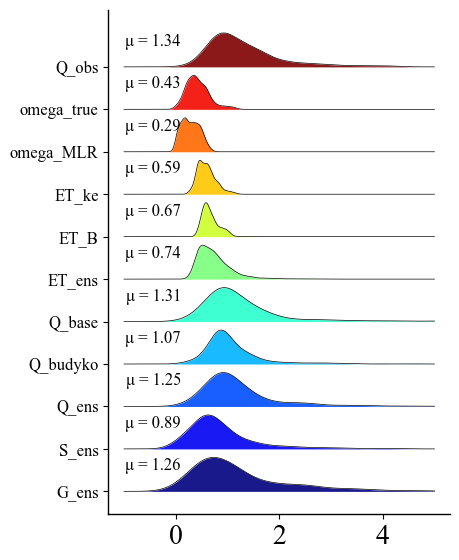

In [48]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.font_manager import FontProperties
from scipy.stats import gaussian_kde


# ============================================================
# Font / style
# ============================================================
font_path_regular = r"C:/Windows/Fonts/times.ttf"
font_prop = FontProperties(fname=font_path_regular)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20


# ============================================================
# Paths
# ============================================================
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BASE_MODEL"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_MODEL"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_DA"


# ============================================================
# Variables
# ============================================================
target_cols = [
    "Q_obs", "omega_true", "omega_MLR", "ET_ke", "Q_base",
    "ET_B", "Q_budyko",
    "S_ens", "G_ens", "ET_ens", "Q_ens"
]

variable_order = [
    "Q_obs", "omega_true", "omega_MLR",
    "ET_ke", "ET_B", "ET_ens",
    "Q_base", "Q_budyko", "Q_ens",
    "S_ens", "G_ens"
]


def scenario_of(var):
    if var in ("Q_obs", "omega_true", "omega_MLR", "ET_ke", "Q_base"):
        return "BASE"
    if var in ("ET_B", "Q_budyko"):
        return "BUDYKO"
    if var in ("S_ens", "G_ens", "ET_ens", "Q_ens"):
        return "DA"
    return np.nan


cmap = cm.get_cmap("coolwarm")
scenario_colors = {
    "BASE":   cmap(0.15),
    "BUDYKO": cmap(0.50),
    "DA":     cmap(0.85),
}


# ============================================================
# File listing
# ============================================================
def list_files(ddir, pattern):
    return sorted(glob.glob(os.path.join(ddir, pattern)))


base_files   = list_files(RESULT_DIR_BASE,   "results_BASE_*.feather")
budyko_files = list_files(RESULT_DIR_BUDYKO, "results_BUDYKO_*.feather")

# ✅ DA files now contain ensemble MEANS in feather
# e.g., columns: ET_ens_mean, Q_ens_mean, S_ens_mean, G_ens_mean
da_files     = list_files(RESULT_DIR_DA,     "enkf_ensemble_BUDYKO_DA_*.feather")

if len(base_files) == 0 and len(budyko_files) == 0 and len(da_files) == 0:
    raise FileNotFoundError("No BASE/BUDYKO feather files or DA (enkf_ensemble_*.feather) files were found.")


# ============================================================
# CV helper
# ============================================================
def cv_of_array(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    m = np.nanmean(x)
    s = np.nanstd(x, ddof=1)
    if (not np.isfinite(m)) or m == 0 or (not np.isfinite(s)):
        return np.nan
    return float(s / abs(m))


cv_list = {}


# ------------------------
# BASE (feather)
# ------------------------
for f in base_files:
    basin_id = os.path.basename(f).replace(".feather", "")

    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})

    for col in ("Q_obs", "omega_true", "omega_MLR", "ET_ke", "Q_base"):
        if col in df.columns:
            cvs[col] = cv_of_array(pd.to_numeric(df[col], errors="coerce").to_numpy())
        else:
            cvs[col] = np.nan

    cv_list[basin_id] = cvs


# ------------------------
# BUDYKO (feather)
# ------------------------
for f in budyko_files:
    basin_id = os.path.basename(f).replace(".feather", "")

    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})

    for col in ("ET_B", "Q_budyko"):
        if col in df.columns:
            cvs[col] = cv_of_array(pd.to_numeric(df[col], errors="coerce").to_numpy())
        else:
            cvs[col] = np.nan

    cv_list[basin_id] = cvs


# ------------------------
# DA (enkf ensemble MEAN feather)
# - map: ET_ens <- ET_ens_mean, Q_ens <- Q_ens_mean, S_ens <- S_ens_mean, G_ens <- G_ens_mean
# ------------------------
for f in da_files:
    fname = os.path.basename(f)

    # keep EXACT basin_id convention used previously: file stem as basin_id
    basin_id = fname.replace(".feather", "")

    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})

    # exact columns you reported
    for out_name, src_col in [
        ("ET_ens", "ET_ens_mean"),
        ("Q_ens",  "Q_ens_mean"),
        ("S_ens",  "S_ens_mean"),
        ("G_ens",  "G_ens_mean"),
    ]:
        if src_col in df.columns:
            cvs[out_name] = cv_of_array(pd.to_numeric(df[src_col], errors="coerce").to_numpy())
        else:
            cvs[out_name] = np.nan

    cv_list[basin_id] = cvs


# ============================================================
# Build CV dataframe with ALL target columns
# ============================================================
cv_df = pd.DataFrame.from_dict(cv_list, orient="index")
cv_df.index.name = "basin"

# ensure all target columns exist (even if missing)
for c in target_cols:
    if c not in cv_df.columns:
        cv_df[c] = np.nan

cv_df = cv_df[target_cols]


# ============================================================
# Long format
# ============================================================
cv_df_long = (
    cv_df.reset_index()
    .melt(id_vars="basin", var_name="variable", value_name="cv")
)

cv_df_long["cv"] = pd.to_numeric(cv_df_long["cv"], errors="coerce")
cv_df_long["scenario"] = cv_df_long["variable"].map(scenario_of)

levels = list(reversed(variable_order))
cmap = cm.get_cmap("jet", len(levels))
var_colors = {var: cmap(i) for i, var in enumerate(levels)}

cv_df_long["variable"] = pd.Categorical(cv_df_long["variable"], categories=levels, ordered=True)
cv_df_long = cv_df_long.sort_values("variable")


# ============================================================
# Stats (mean/median)
# ============================================================
cv_stats = (
    cv_df_long.groupby("variable", observed=True)["cv"]
    .agg(mean_cv="mean", median_cv="median")
    .reset_index()
)

cv_stats["label"] = cv_stats.apply(
    lambda r: (
        "μ = NA, median = NA"
        if pd.isna(r["mean_cv"]) else
        f"μ = {r['mean_cv']:.2f}"
    ),
    axis=1
)


# ============================================================
# Ridge plot (ggplot-like)
# ============================================================
x_min, x_max = -1, 5
x_grid = np.linspace(x_min, x_max, 500)

fig, ax = plt.subplots(figsize=(5, 6))

y_levels = levels
y_positions = np.arange(len(y_levels))

for i, var in enumerate(y_levels):
    vals = cv_df_long.loc[cv_df_long["variable"] == var, "cv"].values
    vals = vals[np.isfinite(vals)]
    scen = scenario_of(var)

    if vals.size < 5:
        dens = np.zeros_like(x_grid)
    else:
        kde = gaussian_kde(vals)
        dens = kde(x_grid)
        if np.nanmax(dens) > 0:
            dens = dens / np.nanmax(dens) * 0.8

    fill_col = var_colors.get(var, "#dddddd")

    ax.fill_between(x_grid, i, i + dens, color=fill_col, alpha=0.9, linewidth=0)
    ax.plot(x_grid, i + dens, color="black", linewidth=0.5)

ax.set_yticks(y_positions)
ax.set_yticklabels(y_levels, fontsize=12, fontproperties=font_prop)

ax.set_xlabel("")
ax.set_ylabel("")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

x_text = 0.1
for i, var in enumerate(y_levels):
    row = cv_stats[cv_stats["variable"].astype(str) == var]
    label = row["label"].values[0] if not row.empty else "μ = NA, median = NA"
    ax.text(
        x_text, i + 0.40, label,
        ha="right", va="bottom",
        fontsize=12, fontproperties=font_prop,
        clip_on=False
    )

plt.tight_layout()
plt.show()


In [ ]:
ssh-keygen -t ed25519 -C "habtemodel1345@gmail.com"


# Dynamic Budyko + Omega distribution:

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_32784\3574925183.py:230: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


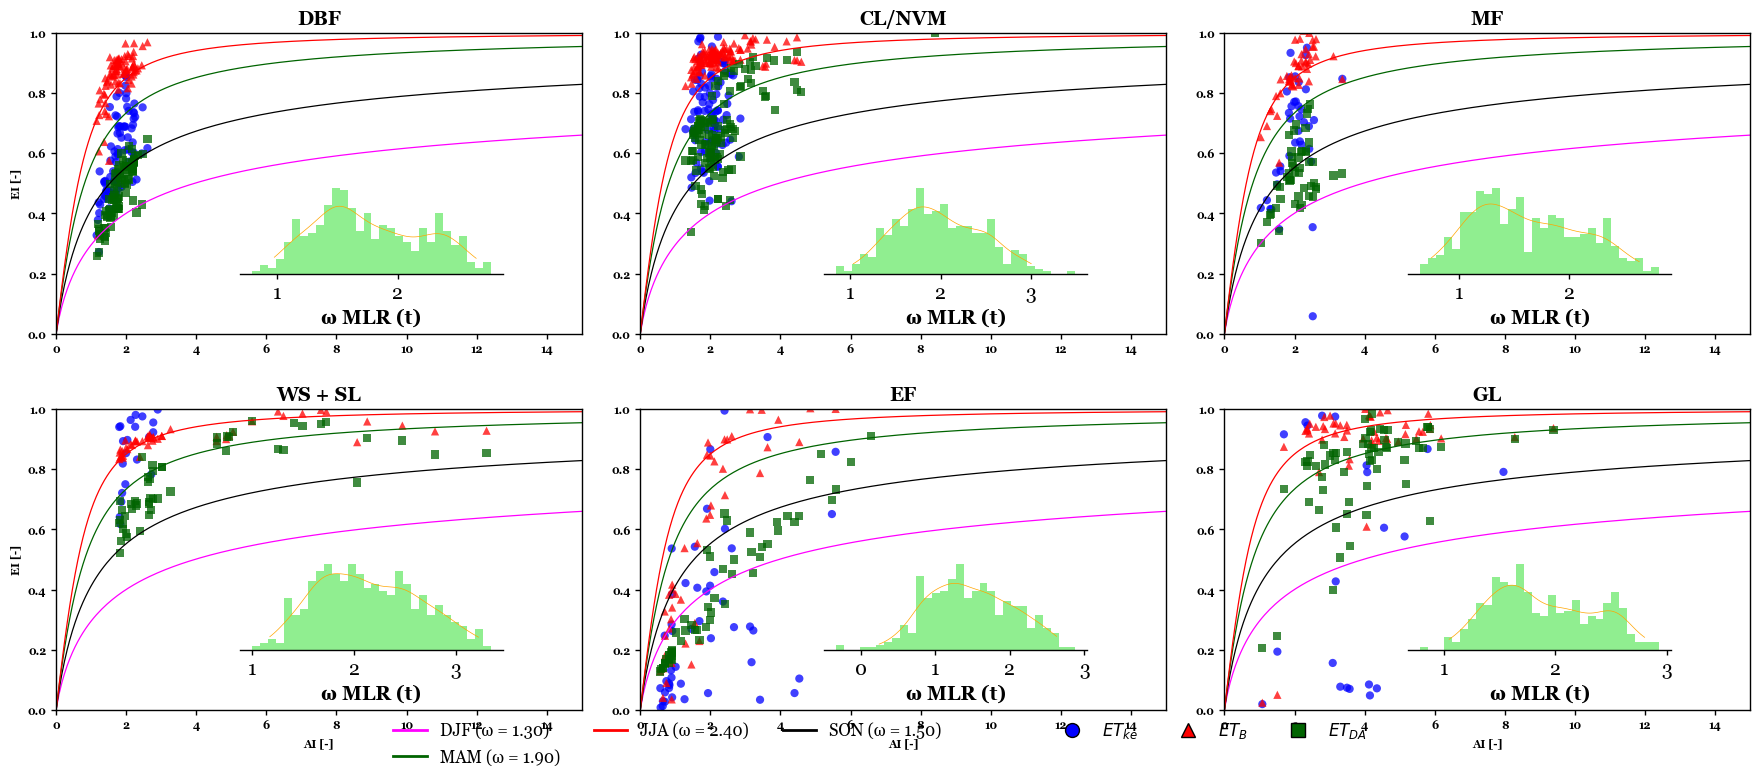

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# GLOBAL STYLE (theme_bw(base_family="Georgia"))
# ============================================================
plt.rcParams["font.family"] = "Georgia"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["xtick.major.width"] = 1.0
plt.rcParams["ytick.major.width"] = 1.0

# ============================================================
# LOAD DATA
# ============================================================
INPUT_CSV_PATH = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\attrs_SFET_geo_KGE.csv"
df = pd.read_csv(INPUT_CSV_PATH)

df["dom_land_cover_short"] = df["dom_land_cover_short"].astype(str)

# ============================================================
# BUDYKO FUNCTION (Fu)
# ============================================================
def Fu(AI, omega):
    AIc = np.maximum(AI, 1e-6)
    return 1 + AIc - (1 + AIc**omega) ** (1.0 / omega)

AI_range = np.concatenate(([0], np.linspace(0.01, 15, 199)))
dom_land_covers = ["DBF", "CL/NVM", "MF", "WS + SL", "EF", "GL"]

# ============================================================
# SEASONS & OMEGA VALUES
# ============================================================
seasons = ["DJF", "MAM", "JJA", "SON"]

omega_seasonal_mean = pd.DataFrame({
    "season": seasons,
    "omega": [1.3, 1.9, 2.4, 1.5]   # same as your R code
}).sort_values("omega")

season_order = omega_seasonal_mean["season"].tolist()

season_colors = {
    "DJF": "magenta",
    "MAM": "darkgreen",
    "JJA": "red",
    "SON": "black"
}

season_labels = {
    row["season"]: f"{row['season']} (ω = {row['omega']:.2f})"
    for _, row in omega_seasonal_mean.iterrows()
}

# ============================================================
# SCENARIOS (models)
# ============================================================
model_items = ["ET_ke", "ET_B", "ET_DA"]
model_colors = {
    "ET_ke": "blue",
    "ET_B": "red",
    "ET_DA": "darkgreen"
}
model_markers = {
    "ET_ke": "o",   # 19 filled circle
    "ET_B": "^",    # 17 triangle
    "ET_DA": "s"    # 15 square
}

# mapping AI/EI columns
model_map = {
    "ET_ke": ("AI_ke",  "EI_ke"),
    "ET_B":  ("AI_B",   "EI_B"),
    "ET_DA": ("AI_ass", "EI_ass")
}

# ============================================================
# BUILD PANELS
# ============================================================



fig, axes = plt.subplots(2, 3, figsize=(18, 8))#, dpi=300)
axes = axes.flatten()

np.random.seed(123)

for i, lc in enumerate(dom_land_covers):

    ax = axes[i]
    filtered = df[df["dom_land_cover_short"] == lc].copy()

    # ----------------------------------------------------------
    # SEASONAL BUDYKO CURVES
    # ----------------------------------------------------------
    for ss in season_order:
        om = float(omega_seasonal_mean.loc[omega_seasonal_mean["season"] == ss, "omega"].values[0])
        EI_curve = Fu(AI_range, om)
        ax.plot(AI_range, EI_curve, color=season_colors[ss], linewidth=0.9)

    # ----------------------------------------------------------
    # SCATTER DATA
    # ----------------------------------------------------------
    for nm in model_items:
        ai_col, ei_col = model_map[nm]
        if ai_col in filtered.columns and ei_col in filtered.columns:
            plot_data = filtered[[ai_col, ei_col]].rename(columns={ai_col: "AI", ei_col: "EI"})
            plot_data = plot_data[np.isfinite(plot_data["AI"]) & np.isfinite(plot_data["EI"])]

            ax.scatter(
                plot_data["AI"], plot_data["EI"],
                s=35,
                alpha=0.75,
                color=model_colors[nm],
                marker=model_markers[nm],
                edgecolor="none"
            )

    # ----------------------------------------------------------
    # VEGETATION-SPECIFIC OMEGA DISTRIBUTION INSET
    # ----------------------------------------------------------
    veg_mean_shift = [0.00, 0.20, -0.15, 0.35, -0.30, 0.10][i]
    veg_sd         = [0.18, 0.25, 0.22, 0.30, 0.35, 0.20][i]

    omega_samples = []
    for mu in omega_seasonal_mean["omega"].values:
        omega_samples.append(np.random.normal(loc=mu + veg_mean_shift, scale=veg_sd, size=100))
    omega_dist = np.concatenate(omega_samples)

    q01, q99 = np.quantile(omega_dist, [0.01, 0.99])

    # inset axes
    iax = inset_axes(
        ax,
        width="50%", height="30%",
        loc="lower left",
        bbox_to_anchor=(0.35, 0.2, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    # histogram density
    bins = 30
    iax.hist(
        omega_dist,
        bins=bins,
        density=True,
        color="lightgreen",
        edgecolor="black",
        linewidth=0
    )

    # density line
    kde = gaussian_kde(omega_dist)
    x_kde = np.linspace(q01, q99, 100)
    y_kde = kde(x_kde)
    iax.plot(x_kde, y_kde, color="orange", linewidth=0.5)

    # iax.set_xlim(q01, q99)
    iax.set_yticks([])

    iax.set_xlabel("ω MLR (t)", fontsize=14)
    iax.tick_params(axis="x", labelsize=14)
    for spine in ["top", "right", "left"]:
        iax.spines[spine].set_visible(False)

    # ----------------------------------------------------------
    # PANEL FORMATTING
    # ----------------------------------------------------------
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 1)

    # Title bold (like element_markdown **lc**)
    ax.set_title(lc, fontsize=14, fontweight="bold")

    # axis labels only for selected panels (same logic as R)
    ax.set_xlabel("AI [-]" if (i+1) in [4, 5, 6] else "")
    ax.set_ylabel("EI [-]" if (i+1) in [1, 4] else "")

    # ticks bold
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

# ============================================================
# BUILD ONE SHARED LEGEND (bottom)
# ============================================================
legend_handles = []

# seasons (lines)
for ss in seasons:
    legend_handles.append(
        Line2D([0], [0], color=season_colors[ss], lw=2,
               label=season_labels[ss])
    )

# models (points)
legend_handles.append(Line2D([], [], color="none", label=""))  # spacer

legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_ke"], color="none",
           markerfacecolor=model_colors["ET_ke"], markersize=10, label=r"$ET_{ke}$")
)
legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_B"], color="none",
           markerfacecolor=model_colors["ET_B"], markersize=10, label=r"$ET_{B}$")
)
legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_DA"], color="none",
           markerfacecolor=model_colors["ET_DA"], markersize=10, label=r"$ET_{DA}$")
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=7,
    frameon=False,
    fontsize=12,
    handlelength=2
)
plt.tight_layout()
# plt.subplots_adjust(bottom=0.18, wspace=0.25, hspace=0.35)
plt.show()


# All Scenarios: Simulations:

In [46]:


plt.rcParams["font.family"] = "Georgia"
plt.rcParams["font.size"] = 12

# ------------------------------------------------
# Paths to results folders
# ------------------------------------------------
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BASE_MODEL"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_MODEL"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_DA"

RESULT_DIRS = [RESULT_DIR_BASE, RESULT_DIR_BUDYKO, RESULT_DIR_DA]

# ------------------------------------------------
# Target columns from feather outputs
# ------------------------------------------------ 

target_cols = [
    "omega_true", "omega_MLR",
    "P", "PET",
    "ET_ke", "ET_B", "ET_ass","S_base", "G_base", "S_budyko", "G_budyko",
    "Q_obs", "Q_base", "Q_budyko", "Q_ass", "Q_ens",
]

# ------------------------------------------------
# Helper: gauge_id from filename (handles *.feather.npz correctly)
# ------------------------------------------------
def get_gauge_id(fname):
    base = os.path.basename(fname)

    # remove trailing .npz
    if base.endswith(".npz"):
        base = base[:-4]

    # remove trailing .feather (in case of *.feather.npz)
    if base.endswith(".feather"):
        base = base[:-8]

    # split
    stem = os.path.splitext(base)[0]
    return stem.split("_")[-1].strip()

def safe_mean(arr):
    arr = np.asarray(arr, dtype=float).ravel()
    arr = arr[np.isfinite(arr)]
    return float(np.nanmean(arr)) if arr.size > 0 else np.nan

# ------------------------------------------------
# Part A: Read all feather basin results and compute mean
# ------------------------------------------------
records = []

for Result_DIR in RESULT_DIRS:
    for fname in tqdm(os.listdir(Result_DIR), desc=f"Processing feather in {os.path.basename(Result_DIR)}"):
        if fname.startswith("results_") and fname.endswith(".feather"):

            basin_id = get_gauge_id(fname)
            fpath = os.path.join(Result_DIR, fname)

            try:
                df = feather.read_feather(fpath)

                cols_present = [c for c in target_cols if c in df.columns]
                if not cols_present:
                    continue

                rec = {"gauge_id": basin_id}
                for c in cols_present:
                    rec[c] = df[c].mean(skipna=True)

                records.append(rec)

            except Exception as e:
                print(f"⚠️ Skipping {basin_id} in {Result_DIR}: {e}")

summary_df = pd.DataFrame(records)
summary_df = summary_df.sort_values(by="gauge_id").reset_index(drop=True)

# merge BASE + BUDYKO + DA rows per basin
summary_df = (
    summary_df.groupby("gauge_id", as_index=False)
    .apply(lambda g: g.ffill().bfill().iloc[0])
    .reset_index(drop=True)
)

all_simu_mean_505_basins = summary_df.set_index("gauge_id")

# ------------------------------------------------
# Part B: Read EnKF ensemble .npz files and add summary columns
# ------------------------------------------------
npz_records = []

ensemble_files = [
    f for f in os.listdir(RESULT_DIR_DA)
    if f.startswith("enkf_ensemble_BUDYKO_DA_") and f.endswith(".npz")
]

for fname in tqdm(ensemble_files, desc="Processing ensemble npz in BUDYKO_DA"):
    basin_id = get_gauge_id(fname)
    fpath = os.path.join(RESULT_DIR_DA, fname)

    try:
        z = np.load(fpath, allow_pickle=False)

        rec = {"gauge_id": basin_id}

        rec["S_ens_mean"]  = safe_mean(z["S_ens"])  if "S_ens"  in z.files else np.nan
        rec["G_ens_mean"]  = safe_mean(z["G_ens"])  if "G_ens"  in z.files else np.nan
        rec["ET_ens_mean"] = safe_mean(z["ET_ens"]) if "ET_ens" in z.files else np.nan
        # rec["Q_ens_mean"]  = safe_mean(z["Q_ens"])  if "Q_ens"  in z.files else np.nan

        npz_records.append(rec)

    except Exception as e:
        print(f"⚠️ Skipping ensemble file {fname}: {e}")

npz_df = pd.DataFrame(npz_records).set_index("gauge_id")

# join to main table
all_simu_mean_505_basins = all_simu_mean_505_basins.join(npz_df, how="left")

all_simu_mean_505_basins


Processing feather in BUDYKO_DA: 100%|██████████| 1011/1011 [00:00<00:00, 1861.12it/s]
C:\Users\hdagne1\AppData\Local\Temp\ipykernel_7960\2350349749.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.ffill().bfill().iloc[0])
Processing ensemble npz in BUDYKO_DA: 100%|██████████| 505/505 [00:09<00:00, 51.69it/s]


,omega_true,omega_MLR,P,PET,ET_ke,S_base,G_base,Q_obs,Q_base,ET_B,S_budyko,G_budyko,Q_budyko,ET_ass,Q_ass,Q_ens,S_ens_mean,G_ens_mean,ET_ens_mean
gauge_id,,,,,,,,,,,,,,,,,,,
01013500,1.359970,1.359970,69.008972,114.066348,24.022373,129.048363,75.400808,53.735591,44.511050,26.841142,124.426246,72.681936,41.733779,24.019643,44.513799,45.142236,128.914861,79.514665,24.019643
01022500,1.836808,1.836808,86.182610,135.771404,44.288632,63.379212,2.812542,69.326051,42.827362,45.931256,60.779508,2.703322,40.350065,43.144380,42.881803,43.119919,63.248853,2.911494,43.144380
01030500,1.582447,1.582447,85.258507,124.251547,45.923372,116.545588,20.601201,59.447724,39.974853,42.614858,124.907722,21.661025,43.183425,45.726382,40.024075,40.739396,115.968856,27.534518,45.726382
01031500,1.513462,1.513462,83.229645,120.539311,39.850296,111.480780,7.412783,63.708759,42.849592,38.586472,115.564191,7.670702,44.158176,39.819916,42.879945,42.183120,110.162349,7.527081,39.819916
01047000,1.585004,1.585004,91.036514,114.351780,38.273541,293.419730,5.510682,70.092538,52.554203,39.086723,293.185424,5.506713,51.780073,38.277426,52.550334,53.920695,293.177493,6.392901,38.277426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14306500,1.687183,1.702953,159.861496,145.714540,43.146075,96.784901,40.805152,114.803066,126.845867,33.257418,100.049302,42.164955,129.836480,32.448906,127.575037,122.194269,88.800677,40.420183,32.448906
14309500,2.279180,2.306463,114.539581,178.214207,69.360969,73.888903,30.898421,70.722841,75.698696,35.805090,84.293397,35.175602,83.716833,37.834705,76.572007,77.798833,74.888672,32.465966,37.834705
14316700,1.452383,1.466140,112.465584,164.051385,27.921546,70.972291,11.083797,86.342345,90.493001,26.889481,70.613745,11.027276,90.051877,14.830144,98.782101,99.154828,77.718843,12.174141,14.830144


In [34]:
r = requests.get("https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attributes_v2.0.feather")
attrs = gpd.read_feather(io.BytesIO(r.content))
r = requests.get("https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attrs_v2_streamflow_v1p2.nc")
attrs = attrs.reset_index(drop=False)

In [40]:
attrs_all_simu_mean_505_basins = all_simu_mean_505_basins.merge(attrs, on='gauge_id',how='left')
attrs_all_simu_mean_505_basins

,gauge_id,omega_true,omega_MLR,P,PET,ET_ke,Q_obs,Q_base,ET_B,Q_budyko,...,area_gages2,area_geospa_fabric,geol_1st_class,glim_1st_class_frac,geol_2nd_class,glim_2nd_class_frac,carbonate_rocks_frac,geol_porostiy,geol_permeability,geometry
0,01013500,1.359970,1.359970,69.008972,114.066348,24.022373,53.735591,44.511050,26.841142,41.733779,...,2252.70,2303.95,Siliciclastic sedimentary rocks,0.815904,Basic volcanic rocks,0.179729,0.000000,0.1714,-14.7019,"MULTIPOLYGON (((-68.3565 46.90311, -68.35612 4..."
1,01022500,1.836808,1.836808,86.182610,135.771404,44.288632,69.326051,42.827362,45.931256,40.350065,...,573.60,620.38,Acid plutonic rocks,0.590658,Siliciclastic sedimentary rocks,0.164618,0.000000,0.0710,-14.2138,"POLYGON ((-67.97836 44.6131, -67.978 44.61303,..."
2,01030500,1.582447,1.582447,85.258507,124.251547,45.923372,59.447724,39.974853,42.614858,43.183425,...,3676.17,3676.09,Siliciclastic sedimentary rocks,0.573305,Metamorphics,0.287010,0.052140,0.1178,-14.4918,"MULTIPOLYGON (((-67.83991 45.36614, -67.83954 ..."
3,01031500,1.513462,1.513462,83.229645,120.539311,39.850296,63.708759,42.849592,38.586472,44.158176,...,769.05,766.53,Siliciclastic sedimentary rocks,0.448928,Metamorphics,0.443863,0.026258,0.0747,-14.8410,"MULTIPOLYGON (((-69.3381 45.12316, -69.33799 4..."
4,01047000,1.585004,1.585004,91.036514,114.351780,38.273541,70.092538,52.554203,39.086723,51.780073,...,909.10,904.94,Metamorphics,0.308488,Acid plutonic rocks,0.288613,0.000000,0.0522,-14.4819,"POLYGON ((-70.10847 45.21669, -70.10858 45.216..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,14306500,1.687183,1.702953,159.861496,145.714540,43.146075,114.803066,126.845867,33.257418,129.836480,...,857.16,860.65,Siliciclastic sedimentary rocks,0.799090,Basic volcanic rocks,0.137016,0.000000,0.1701,-14.6983,"POLYGON ((-123.76418 44.48165, -123.76407 44.4..."
501,14309500,2.279180,2.306463,114.539581,178.214207,69.360969,70.722841,75.698696,35.805090,83.716833,...,224.92,226.31,Siliciclastic sedimentary rocks,0.863563,Basic volcanic rocks,0.095225,0.000000,0.1731,-14.8976,"POLYGON ((-123.81322 42.89103, -123.81311 42.8..."
502,14316700,1.452383,1.466140,112.465584,164.051385,27.921546,86.342345,90.493001,26.889481,90.051877,...,587.90,588.01,Basic volcanic rocks,0.444680,Mixed sedimentary rocks,0.373506,0.000000,0.1338,-13.5958,"POLYGON ((-122.49935 43.47688, -122.49971 43.4..."
503,14325000,2.243957,2.272892,184.271652,165.122757,76.550910,120.089625,133.931778,40.553412,145.537781,...,443.07,444.92,Siliciclastic sedimentary rocks,0.903702,Basic plutonic rocks,0.062996,0.000000,0.1708,-15.1799,"POLYGON ((-124.07751 42.89822, -124.07715 42.8..."


In [ ]:
# ============================================================
# Land Cover Mapping
# ============================================================
land_cover_mapping = {
    'Croplands':'CL/NVM',
    'cropland/natural vegetation mosaic':'CL/NVM',
    'Deciduous Broadleaf Forest':'DBF',
    'Evergreen Needleleaf Forest':'EF',
    'Evergreen Broadleaf Forest':'EF',
    'Mixed Forests':'MF',
    'Grasslands':'GL',
    'Savannas':'WS + SL',
    'Woody Savannas':'WS + SL',
    'Closed Shrublands':'WS + SL',
    'Open Shrublands':'WS + SL'
}

attrs_all_simu_mean_505_basins['dom_land_cover_short'] = attrs_all_simu_mean_505_basins['dom_land_cover'].map(land_cover_mapping)
attrs_all_simu_mean_505_basins

,gauge_id,omega_true,omega_MLR,P,PET,ET_ke,Q_obs,Q_base,ET_B,Q_budyko,...,area_geospa_fabric,geol_1st_class,glim_1st_class_frac,geol_2nd_class,glim_2nd_class_frac,carbonate_rocks_frac,geol_porostiy,geol_permeability,geometry,dom_land_cover_short
0,01013500,1.359970,1.359970,69.008972,114.066348,24.022373,53.735591,44.511050,26.841142,41.733779,...,2303.95,Siliciclastic sedimentary rocks,0.815904,Basic volcanic rocks,0.179729,0.000000,0.1714,-14.7019,"MULTIPOLYGON (((-68.3565 46.90311, -68.35612 4...",MF
1,01022500,1.836808,1.836808,86.182610,135.771404,44.288632,69.326051,42.827362,45.931256,40.350065,...,620.38,Acid plutonic rocks,0.590658,Siliciclastic sedimentary rocks,0.164618,0.000000,0.0710,-14.2138,"POLYGON ((-67.97836 44.6131, -67.978 44.61303,...",MF
2,01030500,1.582447,1.582447,85.258507,124.251547,45.923372,59.447724,39.974853,42.614858,43.183425,...,3676.09,Siliciclastic sedimentary rocks,0.573305,Metamorphics,0.287010,0.052140,0.1178,-14.4918,"MULTIPOLYGON (((-67.83991 45.36614, -67.83954 ...",MF
3,01031500,1.513462,1.513462,83.229645,120.539311,39.850296,63.708759,42.849592,38.586472,44.158176,...,766.53,Siliciclastic sedimentary rocks,0.448928,Metamorphics,0.443863,0.026258,0.0747,-14.8410,"MULTIPOLYGON (((-69.3381 45.12316, -69.33799 4...",MF
4,01047000,1.585004,1.585004,91.036514,114.351780,38.273541,70.092538,52.554203,39.086723,51.780073,...,904.94,Metamorphics,0.308488,Acid plutonic rocks,0.288613,0.000000,0.0522,-14.4819,"POLYGON ((-70.10847 45.21669, -70.10858 45.216...",MF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,14306500,1.687183,1.702953,159.861496,145.714540,43.146075,114.803066,126.845867,33.257418,129.836480,...,860.65,Siliciclastic sedimentary rocks,0.799090,Basic volcanic rocks,0.137016,0.000000,0.1701,-14.6983,"POLYGON ((-123.76418 44.48165, -123.76407 44.4...",EF
501,14309500,2.279180,2.306463,114.539581,178.214207,69.360969,70.722841,75.698696,35.805090,83.716833,...,226.31,Siliciclastic sedimentary rocks,0.863563,Basic volcanic rocks,0.095225,0.000000,0.1731,-14.8976,"POLYGON ((-123.81322 42.89103, -123.81311 42.8...",EF
502,14316700,1.452383,1.466140,112.465584,164.051385,27.921546,86.342345,90.493001,26.889481,90.051877,...,588.01,Basic volcanic rocks,0.444680,Mixed sedimentary rocks,0.373506,0.000000,0.1338,-13.5958,"POLYGON ((-122.49935 43.47688, -122.49971 43.4...",EF
503,14325000,2.243957,2.272892,184.271652,165.122757,76.550910,120.089625,133.931778,40.553412,145.537781,...,444.92,Siliciclastic sedimentary rocks,0.903702,Basic plutonic rocks,0.062996,0.000000,0.1708,-15.1799,"POLYGON ((-124.07751 42.89822, -124.07715 42.8...",EF


In [ ]:
attrs_all_simu_mean_505_basins["AI_base"] = attrs_all_simu_mean_505_basins['PET'] / attrs_all_simu_mean_505_basins['P']
attrs_all_simu_mean_505_basins["EI_base"] = attrs_all_simu_mean_505_basins['ET_ke'] / attrs_all_simu_mean_505_basins['P']
attrs_all_simu_mean_505_basins["AI_B"] = attrs_all_simu_mean_505_basins['PET'] / attrs_all_simu_mean_505_basins['P']
attrs_all_simu_mean_505_basins["EI_B"] = attrs_all_simu_mean_505_basins['ET_B'] / attrs_all_simu_mean_505_basins['P']

attrs_all_simu_mean_505_basins["AI_ass"] = attrs_all_simu_mean_505_basins['ET_ass'] / attrs_all_simu_mean_505_basins['P']
attrs_all_simu_mean_505_basins["EI_ass"] = attrs_all_simu_mean_505_basins['ET_ass'] / attrs_all_simu_mean_505_basins['P']

In [70]:
perform = pd.read_csv(
    r'F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BASE_MODEL\metrics_BASE.csv'
)
perform = perform.set_index('gauge_id')

data_dir = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed"
NWM = pd.read_feather(os.path.join(data_dir, "NWM.feather"))
Q_USGS = pd.read_feather(os.path.join(data_dir, "Q_USGS.feather")).set_index("time")
Q_USGS = Q_USGS.loc["2000-01-01":"2014-12-31"]

# ------------------------------------------------------------
# 2. Normalize gauge IDs
# ------------------------------------------------------------
Q_USGS.columns = Q_USGS.columns.astype(str).str.zfill(8)
NWM.columns    = NWM.columns.astype(str).str.zfill(8)
perform_ids    = perform.index.astype(str).str.zfill(8)

# ------------------------------------------------------------
# 3. Keep valid basins only
# ------------------------------------------------------------
valid_ids = sorted(set(perform_ids) & set(Q_USGS.columns) & set(NWM.columns))
print("Valid basins:", len(valid_ids))

Q_USGS_common = Q_USGS[valid_ids]
NWM_common    = NWM[valid_ids]

# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------
def calculate_kge(sim, obs):
    sim, obs = np.asarray(sim), np.asarray(obs)
    mask = np.isfinite(sim) & np.isfinite(obs)
    sim, obs = sim[mask], obs[mask]
    if len(sim) < 3: return np.nan
    cc = np.corrcoef(sim, obs)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta  = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((cc - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def calculate_nse(obs, sim):
    sim, obs = np.asarray(sim), np.asarray(obs)
    mask = np.isfinite(sim) & np.isfinite(obs)
    sim, obs = sim[mask], obs[mask]
    if len(sim) < 3: return np.nan
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2)

# ------------------------------------------------------------
# 5. Compute NWM metrics
# ------------------------------------------------------------
metrics = []
for basin in valid_ids:
    obs = Q_USGS_common[basin]
    sim = NWM_common[basin]
    metrics.append({
        "gauge_id": int(basin),
        "KGE_NWM": calculate_kge(sim, obs),
        "NSE_NWM": calculate_nse(obs, sim)
    })

metrics_df = pd.DataFrame(metrics).set_index("gauge_id")

# ------------------------------------------------------------
# 6. Combine with model performance table
# ------------------------------------------------------------
perform_fixed = perform.reset_index().rename(columns={"gauge_id": "gauge_id"})
perform_fixed["gauge_id"] = perform_fixed["gauge_id"].astype(int)
metrics_df.index = metrics_df.index.astype(int)

nwm_long = pd.DataFrame({
    "gauge_id": metrics_df.index,
    "scenario": "Q_NWM",
    "KGE": metrics_df["KGE_NWM"],
    "NSE": metrics_df["NSE_NWM"],
})

perform_extended = pd.concat([perform_fixed, nwm_long], ignore_index=True)
perform_extended = perform_extended.dropna(subset=["gauge_id", "scenario"])

# ------------------------------------------------------------
# 7. Plotting configurations
# ------------------------------------------------------------
label_map = {
    'Q_ke': 'Q (Base)',
    'Q_b': 'Q (Budyko)',
    'Q_B_ass': 'Q (ET_ass)',
    'Q_nldas': 'Q (NLDAS)',
    'Q_NWM': 'Q (NWM)'
}

unique_scenarios = perform_extended['scenario'].unique()
metrics_list = ['KGE', 'NSE']
palette_list = sns.color_palette('gist_ncar', len(unique_scenarios))
labels = [label_map.get(s, s) for s in unique_scenarios]


Valid basins: 432


In [85]:
attrs_SFET_geo_KGE = pd.read_csv(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\attrs_SFET_geo_KGE.csv")
attrs_SFET_geo_KGE


,Q_B_ass,Q_NWM,Q_b,Q_ke,Q_nldas,omega_true,omega_MLR,P,PET,Qsb,...,AI_ke,AI_B,AI_ass,AI_nldas,EI_ke,EI_B,EI_ass,EI_nldas,EI_SFET,dom_land_cover_short
0,0.471444,-0.116707,0.436056,0.245749,0.299936,3.978425,1.486981,95.217950,130.305035,69.405630,...,1.368492,1.368492,1.368492,1.368492,0.504974,0.637197,0.324140,0.324096,0.014167,DBF
1,0.350496,-0.404289,0.256663,-0.014156,-8.935600,5.077022,1.665356,80.249954,125.487179,55.261055,...,1.563704,1.563704,1.563704,1.563704,0.622354,0.827584,0.354032,0.353970,0.017049,DBF
2,0.591666,-0.371648,0.561546,0.242224,0.183388,5.332918,1.343807,104.964424,121.284558,78.412800,...,1.155483,1.155483,1.155483,1.155483,0.327233,0.706941,0.257335,0.257288,0.014241,DBF
3,0.453344,-0.199440,0.327089,0.120196,0.349355,5.027563,1.483172,90.055210,125.132885,63.178116,...,1.389513,1.389513,1.389513,1.389513,0.457984,0.739616,0.307084,0.307012,0.015034,DBF
4,0.423850,-0.373023,0.298524,-0.008848,-0.516963,5.289248,1.540557,85.837580,120.534684,58.892387,...,1.404218,1.404218,1.404218,1.404218,0.498076,0.766015,0.322493,0.322443,0.015774,DBF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,0.935626,0.029888,0.876640,0.777991,0.459082,3.433771,1.667863,159.861500,145.714540,115.474990,...,0.911505,0.911505,0.911505,0.911505,0.262513,0.400412,0.199095,0.199066,0.009016,EF
423,0.896355,-0.314120,0.783029,0.800329,0.707853,1.633435,2.131042,114.539580,178.214207,79.189080,...,1.555918,1.555918,1.555918,1.555918,0.542393,0.288924,0.265907,0.265895,0.013897,EF
424,0.886031,-0.116577,0.840420,0.704214,0.176800,1.431099,1.486301,112.465580,164.051385,79.122116,...,1.458681,1.458681,1.458681,1.458681,0.269418,0.151387,0.281692,0.281703,0.013989,EF
425,0.864124,-0.181006,0.698340,0.516414,-1.943670,1.202591,2.831131,184.271650,165.122757,135.626450,...,0.896083,0.896083,0.896083,0.896083,0.536395,0.035363,0.167742,0.167755,0.008448,EF


In [ ]:
# NWM
Result_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed"
NWM = pd.read_feather(os.path.join(Result_DIR, "NWM.feather"))

# NLDAS raw
Result_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed"
Q_nldas_mm_monthly = pd.read_feather(os.path.join(Result_DIR, "Q_nldas_mm_monthly.feather"))
Q_nldas_mm_monthly = Q_nldas_mm_monthly.set_index('time')


r = requests.get("https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attributes_v2.0.feather")
attrs = gpd.read_feather(io.BytesIO(r.content))
r = requests.get("https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attrs_v2_streamflow_v1p2.nc")
# attrs = attrs.reset_index(drop=False)


area_km2 = attrs['area_gages2']
area_km2
# Load data and clean column names
SFET = pd.read_csv(r'F:\Data\SFET\SFET_ET.csv')
SFET.columns = SFET.columns.str.replace(r"^USA_", "", regex=True)
SFET.columns = SFET.columns.str.replace(r"\.\d+$", "", regex=True)
SFET.columns = SFET.columns.str.strip()

# Convert 'date' column to datetime and set as index
SFET['time'] = pd.to_datetime(SFET['time'])
SFET['time'] = SFET['time'].dt.strftime('%Y-%m-%d')
SFET = SFET[
    (SFET['time'] >= '2000-03-31') & 
    (SFET['time'] <= '2014-12-31')
]

SFET.set_index('time', inplace=True)

SFET_monthly_2000_2014 = SFET.copy()
SFET_monthly_2000_2014.index = pd.to_datetime(SFET_monthly_2000_2014.index)
SFET_monthly_2000_2014 = SFET_monthly_2000_2014.resample('MS').mean()
SFET_monthly_2000_2014.index = pd.Index(SFET_monthly_2000_2014.index.strftime('%Y-%m-%d'))



col_nldas_sfet = SFET_monthly_2000_2014.columns.intersection(Q_nldas_mm_monthly.columns)
SFET_monthly_2000_2014 = SFET_monthly_2000_2014[col_nldas_sfet]
SFET_monthly_2000_2014


SFET_longterm = SFET_monthly_2000_2014.mean(axis=0).to_frame(name="SFET")
SFET_longterm.reset_index(inplace=True)
SFET_longterm.rename(columns={"index": "gauge_id"}, inplace=True)
SFET_longterm = SFET_longterm.set_index('gauge_id')

# merge
all_simu_mean_505_basins_SFET = all_simu_mean_505_basins.join(SFET_longterm, how='inner')

# all_simu_mean_505_basins_SFET_attrs = all_simu_mean_505_basins_SFET.join(attrs, how='inner')
# all_simu_mean_505_basins_SFET_attrs['Res'] = all_simu_mean_505_basins_SFET_attrs['omega_true'] - all_simu_mean_505_basins_SFET_attrs['omega_MLR']
# all_simu_mean_505_basins_SFET_attrs['EAI_ke'] = all_simu_mean_505_basins_SFET_attrs['PET'] / (all_simu_mean_505_basins_SFET_attrs['ET_ke'] + all_simu_mean_505_basins_SFET_attrs['ET_ke'])



In [90]:
SFET_monthly_2000_2014

,01013500,01022500,01030500,01031500,01047000,01052500,01054200,01055000,01057000,01073000,...,14301000,14303200,14305500,14306340,14306500,14309500,14316700,14325000,14362250,14400000
time,,,,,,,,,,,,,,,,,,,,,
2000-03-01,0.563525,0.897485,0.692936,0.668471,0.628754,0.473688,0.656156,0.730647,0.781809,1.320996,...,1.858164,2.015754,2.005878,2.173655,2.170275,1.984994,2.070839,2.012765,2.237309,1.952930
2000-04-01,0.605063,0.836660,0.729489,0.712227,0.758282,0.717630,0.800980,0.792205,0.867138,1.072175,...,1.523295,1.604649,1.642958,1.757398,1.742841,1.863227,1.870202,1.742301,1.732517,1.811293
2000-05-01,1.460499,1.720961,1.584668,1.505537,1.477000,1.440918,1.510751,1.521801,1.628574,1.878832,...,1.856514,1.955264,1.966798,2.180920,2.164021,2.398794,2.416485,2.151727,2.452823,2.337572
2000-06-01,2.049409,2.279426,2.143032,2.112477,2.003632,1.900976,1.950736,1.950854,2.115244,2.311801,...,2.477507,2.669880,2.693059,2.865601,2.852074,3.118782,3.093508,3.094113,3.322197,3.030735
2000-07-01,2.409327,2.717808,2.459161,2.436880,2.385258,2.406782,2.456671,2.370122,2.493461,2.751334,...,2.693954,2.784238,2.779253,2.995194,2.963382,3.416054,3.365458,3.321615,3.297981,3.323039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-08-01,2.808078,3.084496,2.865929,2.790405,2.595511,2.493096,2.564721,2.634484,2.746117,3.043696,...,2.912016,2.754277,2.548554,2.792375,2.655160,2.264804,2.024477,2.929158,3.085342,2.019801
2014-09-01,1.527950,1.947512,1.748781,1.712609,1.688059,1.607650,1.671286,1.727489,1.786506,2.063909,...,1.713824,1.647029,1.531959,1.770859,1.731030,1.467970,1.375574,1.853866,1.959924,1.353662
2014-10-01,0.635665,0.744822,0.734900,0.630151,0.638630,0.590160,0.610231,0.649788,0.672633,0.762179,...,0.759161,0.762485,0.761131,0.918614,0.836177,1.031890,0.977896,0.900377,1.003940,0.950139


## Dynamic omega :

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# ------------------------------------------------
# Result folders
# ------------------------------------------------
RESULT_DIRS = [
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BASE_MODEL",
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_MODEL",
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_DA",
]

# ------------------------------------------------
# Target columns to extract from each basin file
# ------------------------------------------------
target_cols = [
    "Q_obs", "omega_true", "omega_MLR",

    "P", "PET", "M",

    "ET_ke", "ET_B", "ET_ens",
    "ET_nldas", "ET_ke_NLDAS_ass",

    "S_ke", "S_b", "S_ens",

    "Q_base", "Q_budyko", "Q_ens",
    "Q_nldas", "Q_ke", "Q_ke_NLDA",

    "Q_b_DA", "Q_b_ETNL_DA"
]


# ------------------------------------------------
# Iterate over all basin files in ALL folders and compute mean
# ------------------------------------------------
records = []

for Result_DIR in RESULT_DIRS:

    if not os.path.isdir(Result_DIR):
        print(f"⚠️ Folder not found: {Result_DIR}")
        continue

    for fname in tqdm(os.listdir(Result_DIR), desc=f"Processing files in: {os.path.basename(Result_DIR)}"):

        # accept any result feather inside these folders
        if fname.startswith("results_") and fname.endswith(".feather"):

            # gauge_id is always last part after underscore
            # examples:
            # results_BASE_01013500.feather -> 01013500
            # results_BUDYKO_01013500.feather -> 01013500
            # results_BUDYKO_DA_01013500.feather -> 01013500
            basin_id = fname.replace(".feather", "").split("_")[-1]

            fpath = os.path.join(Result_DIR, fname)

            try:
                df = pd.read_feather(fpath)

                # only keep expected columns
                cols_present = [c for c in target_cols if c in df.columns]
                if not cols_present:
                    continue

                # compute long-term mean for each variable
                rec = {'gauge_id': basin_id}
                for c in cols_present:
                    rec[c] = df[c].sum(skipna=True) / len(df)

                records.append(rec)

            except Exception as e:
                print(f"⚠️ Skipping {basin_id} from {Result_DIR}: {e}")

# ------------------------------------------------
# Combine all into a single summary DataFrame
# ------------------------------------------------
summary_df = pd.DataFrame(records)

summary_df = summary_df.sort_values(by='gauge_id').reset_index(drop=True)

# if basin repeated across folders, keep first non-null per gauge_id
summary_df = summary_df.groupby("gauge_id", as_index=False).first()

all_simu_mean_505_basins = summary_df.set_index('gauge_id')

all_simu_mean_505_basins_SFET_attrs = all_simu_mean_505_basins.copy()

all_simu_mean_505_basins_SFET_attrs


Processing files in: BUDYKO_DA: 100%|██████████| 1011/1011 [00:00<00:00, 1694.09it/s]


,Q_obs,omega_true,omega_MLR,P,PET,ET_ke,Q_base,ET_B,Q_budyko,Q_ens
gauge_id,,,,,,,,,,
01013500,53.735591,1.359970,1.359970,69.008974,114.066348,24.022373,44.511050,26.841142,41.733779,45.160717
01022500,69.326051,1.836808,1.836808,86.182606,135.771404,44.288632,42.827362,45.931256,40.350065,43.113704
01030500,59.447724,1.582447,1.582447,85.258507,124.251547,45.923372,39.974853,42.614858,43.183425,40.771189
01031500,63.708759,1.513462,1.513462,83.229644,120.539311,39.850296,42.849592,38.586472,44.158176,42.187815
01047000,70.092538,1.585004,1.585004,91.036513,114.351780,38.273541,52.554203,39.086723,51.780073,53.726424
...,...,...,...,...,...,...,...,...,...,...
14306500,114.803066,1.687183,1.702953,159.861502,145.714540,43.146075,126.845867,33.257418,129.836480,122.229386
14309500,70.722841,2.279180,2.306463,114.539583,178.214207,69.360969,75.698696,35.805090,83.716833,77.766392
14316700,86.342345,1.452383,1.466140,112.465582,164.051385,27.921546,90.493001,26.889481,90.051877,99.204670


In [82]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.font_manager import FontProperties
from scipy.stats import gaussian_kde
import pyarrow.feather as feather

# ------------------------------------------------
# Fonts
# ------------------------------------------------
font_path_regular = r"C:/Windows/Fonts/times.ttf"
font_prop = FontProperties(fname=font_path_regular)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20

# ------------------------------------------------
# Result folders
# ------------------------------------------------
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BASE_MODEL"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_MODEL"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_DA"

# ------------------------------------------------
# Columns
# ------------------------------------------------
target_cols = [
    "Q_obs","omega_true", "omega_MLR", "ET_ke", "Q_base",
    "ET_B", "Q_budyko",
    "S_ens", "G_ens", "ET_ens", "Q_ens"
]

variable_order = [
    "Q_obs","omega_true", "omega_MLR",
    "ET_ke", "ET_B", "ET_ens",
    "Q_base", "Q_budyko", "Q_ens",
    "S_ens", "G_ens"
]

def scenario_of(var):
    if var in ("Q_obs","omega_true", "omega_MLR", "ET_ke", "Q_base"):
        return "BASE"
    if var in ("ET_B", "Q_budyko"):
        return "BUDYKO"
    if var in ("S_ens", "G_ens", "ET_ens", "Q_ens"):
        return "DA"
    return np.nan

# ------------------------------------------------
# Colors
# ------------------------------------------------
cmap = cm.get_cmap("coolwarm")
scenario_colors = {
    "BASE":   cmap(0.15),
    "BUDYKO": cmap(0.50),
    "DA":     cmap(0.85),
}

# ------------------------------------------------
# Helpers
# ------------------------------------------------
def list_files(ddir, pattern):
    return sorted(glob.glob(os.path.join(ddir, pattern)))

def get_gauge_id(path):
    """
    Extract gauge_id as the last '_' piece before extension.
    Works for:
      results_BASE_01013500.feather
      results_BUDYKO_01013500.feather
      enkf_ensemble_BUDYKO_DA_01013500.npz
    """
    stem = os.path.basename(path)
    stem = os.path.splitext(stem)[0]
    gauge_id = stem.split("_")[-1].strip()
    return gauge_id

def cv_of_array(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    m = np.nanmean(x)
    s = np.nanstd(x, ddof=1)
    if (not np.isfinite(m)) or m == 0 or (not np.isfinite(s)):
        return np.nan
    return float(s / abs(m))

# ------------------------------------------------
# Collect files
# ------------------------------------------------
base_files   = list_files(RESULT_DIR_BASE,   "results_BASE_*.feather")
budyko_files = list_files(RESULT_DIR_BUDYKO, "results_BUDYKO_*.feather")
da_npz_files = list_files(RESULT_DIR_DA,     "enkf_ensemble_BUDYKO_DA_*.npz")

if len(base_files) == 0 and len(budyko_files) == 0 and len(da_npz_files) == 0:
    raise FileNotFoundError("No BASE/BUDYKO feather files or DA npz files were found.")

# ------------------------------------------------
# CV calculation per basin
# ------------------------------------------------
cv_list = {}

# ------------------------
# BASE (feather)
# ------------------------
for f in base_files:
    gauge_id = get_gauge_id(f)

    try:
        df = feather.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(gauge_id, {})

    for col in ("Q_obs","omega_true","omega_MLR","ET_ke","Q_base"):
        if col in df.columns:
            cvs[col] = cv_of_array(pd.to_numeric(df[col], errors="coerce").to_numpy())
        else:
            cvs[col] = np.nan

    cv_list[gauge_id] = cvs

# ------------------------
# BUDYKO (feather)
# ------------------------
for f in budyko_files:
    gauge_id = get_gauge_id(f)

    try:
        df = feather.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(gauge_id, {})

    for col in ("ET_B","Q_budyko"):
        if col in df.columns:
            cvs[col] = cv_of_array(pd.to_numeric(df[col], errors="coerce").to_numpy())
        else:
            cvs[col] = np.nan

    cv_list[gauge_id] = cvs

# ------------------------
# DA (npz)  -> corrected to handle DA file format
# ------------------------
for f in da_npz_files:
    gauge_id = get_gauge_id(f)

    try:
        z = np.load(f, allow_pickle=False)
    except Exception:
        continue

    cvs = cv_list.get(gauge_id, {})

    direct_keys = ("S_ens", "G_ens", "ET_ens", "Q_ens")

    # Case 1: arrays saved directly under those keys
    if any(k in z.files for k in direct_keys):
        for col in direct_keys:
            if col in z.files:
                arr = z[col]
                cvs[col] = cv_of_array(arr.ravel())
            else:
                cvs[col] = np.nan

    # Case 2: saved as ensemble state matrix "X"
    elif "X" in z.files:
        X = z["X"]  # expected (L, state_dim, nens) OR (L, nens, state_dim)

        # force X to (L, state_dim, nens)
        if X.ndim == 3 and X.shape[1] != 6 and X.shape[2] == 6:
            X = np.transpose(X, (0, 2, 1))

        # State vector structure: [S, G, Kperc, Kb, Ke, Cqq]
        S = X[:, 0, :]
        G = X[:, 1, :]

        cvs["S_ens"] = cv_of_array(S.ravel())
        cvs["G_ens"] = cv_of_array(G.ravel())

        # ET/Q might be stored separately or not
        cvs["ET_ens"] = cv_of_array(z["ET_ens"].ravel()) if "ET_ens" in z.files else np.nan
        cvs["Q_ens"]  = cv_of_array(z["Q_ens"].ravel())  if "Q_ens"  in z.files else np.nan

    # Unknown format
    else:
        for col in direct_keys:
            cvs[col] = np.nan

    cv_list[gauge_id] = cvs

# ============================================================
# Build CV dataframe with ALL target columns
# ============================================================
cv_df = pd.DataFrame.from_dict(cv_list, orient="index")
cv_df.index.name = "gauge_id"

for c in target_cols:
    if c not in cv_df.columns:
        cv_df[c] = np.nan

cv_df = cv_df[target_cols]

# ============================================================
# Long format
# ============================================================
cv_df_long = (
    cv_df.reset_index()
    .melt(id_vars="gauge_id", var_name="variable", value_name="cv")
)

cv_df_long["cv"] = pd.to_numeric(cv_df_long["cv"], errors="coerce")
cv_df_long["scenario"] = cv_df_long["variable"].map(scenario_of)

levels = list(reversed(variable_order))
cmap = cm.get_cmap("jet", len(levels))
var_colors = {var: cmap(i) for i, var in enumerate(levels)}

cv_df_long["variable"] = pd.Categorical(
    cv_df_long["variable"], categories=levels, ordered=True
)
cv_df_long = cv_df_long.sort_values("variable")

# ============================================================
# Stats
# ============================================================
cv_stats = (
    cv_df_long.groupby("variable", observed=True)["cv"]
    .agg(mean_cv="mean", median_cv="median")
    .reset_index()
)

cv_stats["label"] = cv_stats.apply(
    lambda r: ("μ = NA" if pd.isna(r["mean_cv"]) else f"μ = {r['mean_cv']:.2f}"),
    axis=1
)


In [76]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import pyarrow.feather as feather

# ------------------------------------------------
# Result folders
# ------------------------------------------------
RESULT_DIRS = {
    "BASE_MODEL":   r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BASE_MODEL",
    "BUDYKO_MODEL": r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_MODEL",
    "BUDYKO_DA":    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\BUDYKO_DA",
}

# ------------------------------------------------
# helper: extract gauge_id from filename
# ------------------------------------------------
def get_gauge_id(fname):
    # works for:
    # results_BASE_01013500.feather
    # results_BUDYKO_01013500.feather
    # enkf_ensemble_BUDYKO_DA_01013500.npz
    stem = os.path.splitext(os.path.basename(fname))[0]
    return stem.split("_")[-1].strip()

# ------------------------------------------------
# Iterate over all files and compute mean
# ------------------------------------------------
records = []

for scenario, Result_DIR in RESULT_DIRS.items():

    # feather files (BASE/BUDYKO)
    feather_files = [
        f for f in os.listdir(Result_DIR)
        if f.endswith(".feather")
    ]

    # npz files (DA)
    npz_files = [
        f for f in os.listdir(Result_DIR)
        if f.endswith(".npz")
    ]

    # -------- feather processing
    for fname in tqdm(feather_files, desc=f"Processing {scenario} feather"):
        basin_id = get_gauge_id(fname)
        fpath = os.path.join(Result_DIR, fname)

        try:
            df = feather.read_feather(fpath)

            rec = {"gauge_id": basin_id}

            for c in df.columns:
                if c == "time":
                    continue
                if pd.api.types.is_numeric_dtype(df[c]):
                    rec[c] = df[c].mean(skipna=True)

            records.append(rec)

        except Exception as e:
            print(f"⚠️ Skipping {scenario} | {basin_id}: {e}")

    # -------- npz processing (DA)
    for fname in tqdm(npz_files, desc=f"Processing {scenario} npz"):
        basin_id = get_gauge_id(fname)
        fpath = os.path.join(Result_DIR, fname)

        try:
            z = np.load(fpath, allow_pickle=False)

            rec = {"gauge_id": basin_id}

            for k in z.files:
                arr = z[k]
                if np.issubdtype(arr.dtype, np.number):
                    rec[k] = np.nanmean(arr)

            records.append(rec)

        except Exception as e:
            print(f"⚠️ Skipping {scenario} | {basin_id}: {e}")

# ------------------------------------------------
# Combine all into a single summary DataFrame
# ------------------------------------------------
summary_df = pd.DataFrame(records)
summary_df = summary_df.sort_values(by="gauge_id").reset_index(drop=True)

all_simu_mean_505_basins = summary_df.set_index("gauge_id")
all_simu_mean_505_basins_SFET_attrs = all_simu_mean_505_basins.copy()

all_simu_mean_505_basins_SFET_attrs


Processing BASE_MODEL feather: 100%|██████████| 505/505 [00:00<00:00, 800.02it/s]
Processing BASE_MODEL npz: 0it [00:00, ?it/s]
Processing BUDYKO_MODEL feather: 100%|██████████| 505/505 [00:00<00:00, 920.92it/s]
Processing BUDYKO_MODEL npz: 0it [00:00, ?it/s]
Processing BUDYKO_DA npz: 100%|██████████| 505/505 [01:21<00:00,  6.21it/s]


,omega_true,omega_MLR,P,PET,ET_ke,Q_obs,Q_base,ET_B,Q_budyko,ET_ass,Q_ass,Q_ens,nens,S_ens,G_ens,ET_ens
gauge_id,,,,,,,,,,,,,,,,
01013500,1.359970,1.359970,69.008972,114.066348,24.022373,53.735591,44.511050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01013500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.160717,1000.0,128.899244,79.881339,24.028066
01013500,NaN,NaN,69.008972,114.066348,NaN,53.735591,NaN,26.841142,NaN,24.028066,44.505345,45.160717,NaN,NaN,NaN,NaN
01013500,NaN,NaN,69.008972,114.066348,NaN,53.735591,NaN,26.841142,41.733779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01022500,NaN,NaN,86.182610,135.771404,NaN,69.326051,NaN,45.931256,NaN,43.145163,42.884466,43.113704,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14325000,2.243957,2.272892,184.271652,165.122757,76.550910,120.089625,133.931778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14400000,NaN,NaN,216.201645,196.470907,NaN,227.684301,NaN,20.355160,201.566467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14400000,1.213454,1.230100,216.201645,196.470907,10.145758,227.684301,207.185787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
all_simu_mean_505_basins_SFET_attrs.dropna(axis=0)

,omega_true,omega_MLR,P,PET,ET_ke,Q_obs,Q_base,ET_B,Q_budyko,ET_ass,Q_ass,Q_ens,nens,S_ens,G_ens,ET_ens
gauge_id,,,,,,,,,,,,,,,,


# Plot KGE:

In [59]:
# -----------------------------------------
# Create NSE and KGE wide-format DataFrames
# -----------------------------------------
NSE_df = (
    perform_extended
    .pivot(index="gauge_id", columns="scenario", values="NSE")
).dropna()

KGE_df = (
    perform_extended
    .pivot(index="gauge_id", columns="scenario", values="KGE")
).dropna()

# -----------------------------------------
# Fix gauge_id formatting
# -----------------------------------------
KGE_df.index = KGE_df.index.astype(str).map(lambda x: '0' + x if not x.startswith('0') else x)
NSE_df.index = NSE_df.index.astype(str).map(lambda x: '0' + x if not x.startswith('0') else x)
attrs_SFET_geo.index = attrs_SFET_geo.index.astype(str).map(lambda x: '0' + x if not x.startswith('0') else x)


# -----------------------------------------
scenario_cols = NSE_df.columns.tolist()
attrs_SFET_geo = attrs_SFET_geo.drop(
    columns=[c for c in scenario_cols if c in attrs_SFET_geo.columns],
    errors="ignore"
)

# -----------------------------------------
# Merge without creating _x suffixes
# -----------------------------------------
attrs_SFET_geo_NSE = NSE_df.merge(
    attrs_SFET_geo,
    left_index=True,
    right_index=True,
    how="inner"
)

attrs_SFET_geo_NSE


# -----------------------------------------
# Merge without creating _x suffixes
# -----------------------------------------
attrs_SFET_geo_KGE = KGE_df.merge(
    attrs_SFET_geo,
    left_index=True,
    right_index=True,
    how="inner"
)

attrs_SFET_geo_KGE


# --------------------- Plotting ----------------------------------
import matplotlib as mpl



# --------------------- Plotting ----------------------------------
try:
    if not isinstance(attrs_SFET_geo_KGE, gpd.GeoDataFrame):
        attrs_SFET_geo_KGE = gpd.GeoDataFrame(
            attrs_SFET_geo_KGE, 
            geometry='geometry'
        )
except Exception as e:
    print(f"Warning: {e}")

possible_kge_cols = ["Q_ke", "Q_b", "Q_B_ass", "Q_nldas", "Q_NWM"]
kge_cols = [c for c in attrs_SFET_geo_KGE.columns if c in possible_kge_cols]
kge_cols = kge_cols[:4]

fig, axs = pplt.subplots(
    ncols=2,
    nrows=2,
    refwidth='4in',
    refheight='2in',
    dpi=200
)

# ---- Common colormap ----
vmin, vmax = -3.0, 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.get_cmap('gist_ncar')

# ---- Create ONE mappable for the colorbar ----
mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# ---- Reproject once ----
projected = attrs_SFET_geo_KGE.to_crs(5070)
states_proj = states.to_crs(5070)

for ax, col in zip(axs, kge_cols):

    states_proj.boundary.plot(ax=ax, edgecolor='black', linewidth=0.3)

    values = projected[col].values
    colors = cmap(norm(values))

    projected.plot(
        ax=ax,
        color=colors,
        edgecolor='none',
        linewidth=0.12
    )

    ax.set_title(col, fontsize=14)
    ax.set_axis_off()

# ---- ONE colorbar ----
ticks = np.linspace(vmin, vmax, 9)

cbar = fig.colorbar(
    mappable,
    ax=axs,
    loc='r',
    ticks=ticks,
    label="KGE [-]",
    width=0.15,
    pad=0.1,
    extend='max'
)

# cbar.set_label("KGE [-]")

pplt.show()


NameError: name 'attrs_SFET_geo' is not defined

# Spatial Mean KGE (overall all models:)

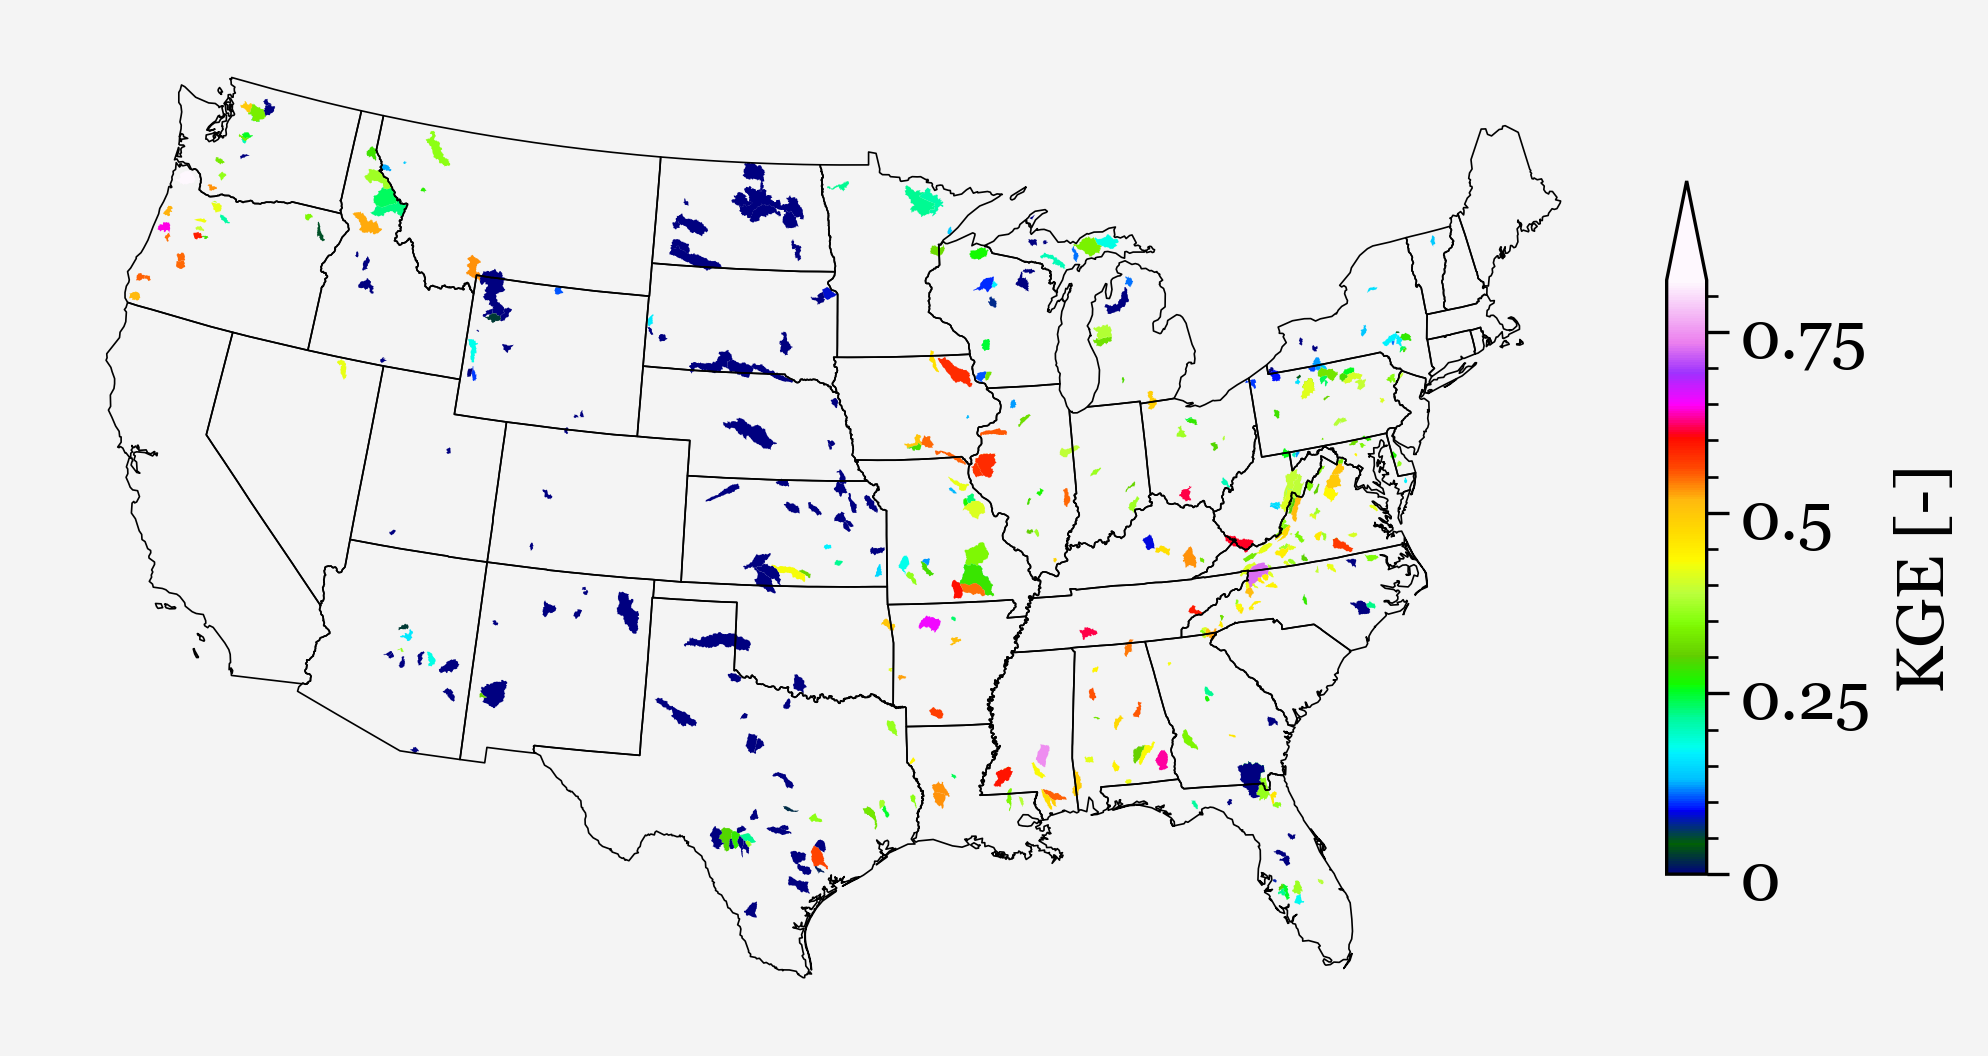

In [13]:
# Compute summary KGE statistics
attrs_SFET_geo_KGE["KGE_mean"] = attrs_SFET_geo_KGE[kge_cols].mean(axis=1)

# SINGLE SPATIAL MAP OF MEAN KGE
fig, ax = pplt.subplots(refwidth='4in', dpi=200)

projected = attrs_SFET_geo_KGE.to_crs(5070)
states_proj = states.to_crs(5070)

states_proj.boundary.plot(ax=ax, edgecolor='black', lw=0.3)

values = projected["KGE_mean"]
norm = mpl.colors.Normalize(vmin=0, vmax=values.max())
cmap = mpl.cm.get_cmap('gist_ncar')
colors = cmap(norm(values))

projected.plot(ax=ax, color=colors, edgecolor='none', linewidth=0.1)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, 
                                   cmap=cmap),
                                   ax=ax, 
                                   loc='r', 
                                   label="KGE [-]",
                                   width=0.1,
                                   length=0.7,
                                   extend='max')

# ax.set_title("Mean KGE Across All Models")
ax.set_axis_off()
pplt.show()


In [14]:
all_simu_mean_505_basins_SFET_attrs['omega_MLR'].min()

1.1541683484505063

In [15]:
all_simu_mean_505_basins_SFET_attrs['omega_true'].mean()

3.1866240225802995

In [16]:
Scenarios_ET = {
    'ET_ke': all_simu_mean_505_basins_SFET_attrs['ET_ke'],
    'ET_B': all_simu_mean_505_basins_SFET_attrs['ET_B'],
    'ET_nldas': all_simu_mean_505_basins_SFET_attrs['ET_nldas'],

}

# Budyko Scape:

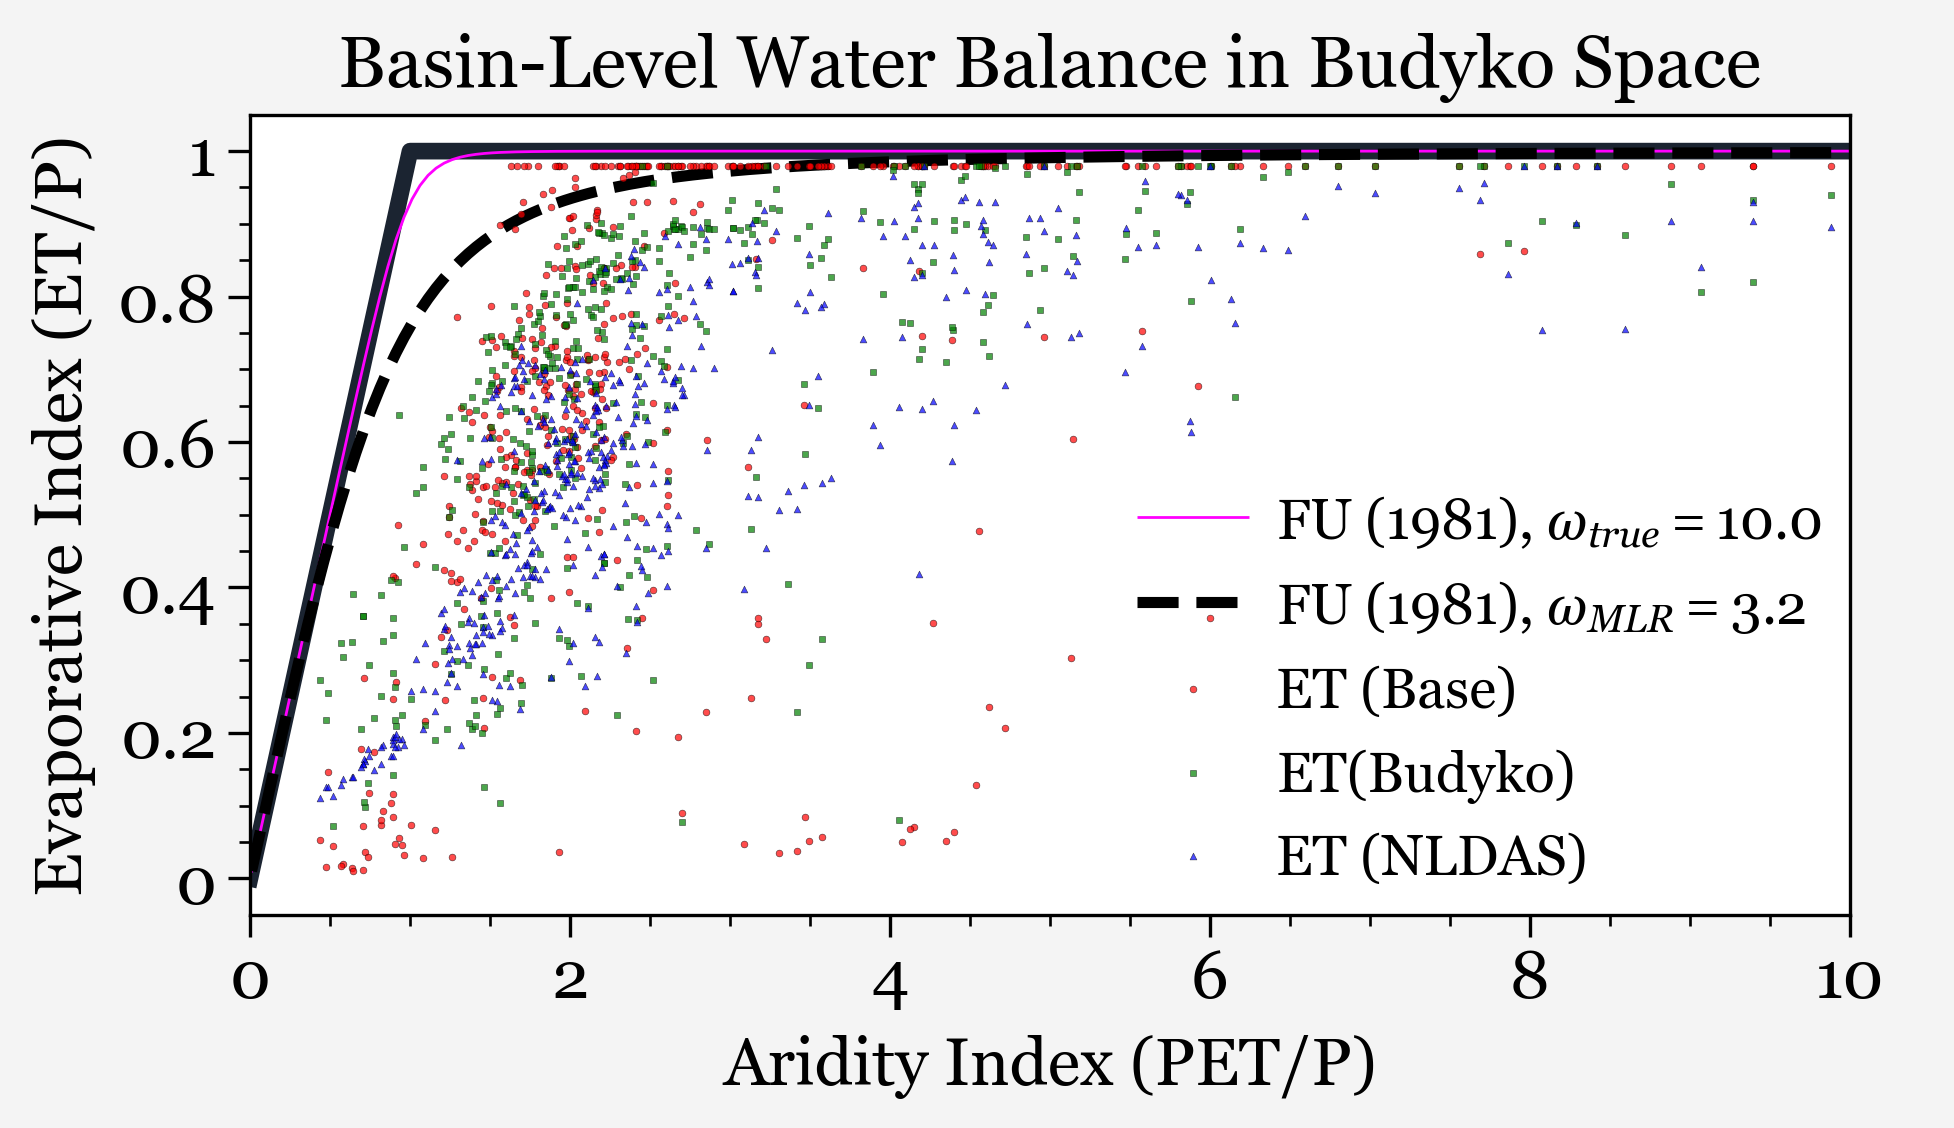


=== LONG-TERM BUDYKO SUMMARY (498 Basins) ===
   AI_mean  EI_ET_ke_mean  EI_ET_B_mean  EI_ET_nldas_mean  omega_true_mean  \
0    2.845          0.688         0.677              0.59             10.0   

   omega_MLR_mean  
0           3.202  


In [17]:

# ============================================================
# 0. INPUTS FROM YOUR REAL DATA (Already Long-Term Means)
# ============================================================

Scenarios_ET = {
    'ET_ke': all_simu_mean_505_basins_SFET_attrs['ET_ke'],
    'ET_B': all_simu_mean_505_basins_SFET_attrs['ET_B'],
    'ET_nldas': all_simu_mean_505_basins_SFET_attrs['ET_nldas'],
}

PRCP_longterm = all_simu_mean_505_basins_SFET_attrs['P']
PET_longterm  = all_simu_mean_505_basins_SFET_attrs['PET']


omega_true_mean = all_simu_mean_505_basins_SFET_attrs['omega_true'].max()
omega_mlr_mean  = all_simu_mean_505_basins_SFET_attrs['omega_MLR'].mean()

# Align by gauge_id
common_ids = PRCP_longterm.index.intersection(PET_longterm.index)
for key in Scenarios_ET:
    common_ids = common_ids.intersection(Scenarios_ET[key].index)

PRCP_longterm = PRCP_longterm.loc[common_ids]
PET_longterm  = PET_longterm.loc[common_ids]

for key in Scenarios_ET:
    Scenarios_ET[key] = Scenarios_ET[key].loc[common_ids]


# ============================================================
# 1. COMPUTE BASIN-LEVEL AI AND EI
# ============================================================

AI_basins = PET_longterm / PRCP_longterm   # PET/P

EI_scenarios = {}
for key, ET_series in Scenarios_ET.items():
    EI_scenarios[key] = (ET_series /  PRCP_longterm).clip(upper=0.98)


# ============================================================
# 2. FU BUDYKO CURVE FUNCTION (YOUR EXACT EQUATION)
# ============================================================

def FU(EAI, omega):
    term1 = EAI
    term2 = term1**omega
    term3 = 1 + term2
    term4 = term3**(1/omega)
    ET  = 1 + term1 - term4
    return ET

BC_AI = np.linspace(0.01, 15.0, 300)

curve_Fu_true = FU(BC_AI, omega_true_mean)
curve_Fu_mlr  = FU(BC_AI, omega_mlr_mean)


# ============================================================
# 3. PLOT SETUP
# ============================================================

colors = {'ET_ke': 'red', 'ET_B': 'green', 'ET_nldas': 'blue'}
markers = {'ET_ke': 'o', 'ET_B': 's', 'ET_nldas': '^'}
labels  = {'ET_ke': 'ET (Base)', 'ET_B': 'ET(Budyko)', 'ET_nldas': 'ET (NLDAS)'}

fig, ax = pplt.subplots(nrows=1, ncols=1, refwidth='4in', refheight='2in', share=1, dpi=200)
ax.plot([0, 1, 15], [0, 1, 1], color='dark', lw=3)

# Two Budyko curves
ax.plot(
    BC_AI, curve_Fu_true,
    color='magenta', lw=0.5,
    label=rf"FU (1981), $\omega_{{true}}={omega_true_mean:.1f}$"
)

ax.plot(
    BC_AI, curve_Fu_mlr,
    color='black', lw=2, ls='--',
    label=rf"FU (1981), $\omega_{{MLR}}={omega_mlr_mean:.1f}$"
)


# Scatter points
for key in Scenarios_ET:
    ax.scatter(
        AI_basins.values,
        EI_scenarios[key].values,
        color=colors[key],
        marker=markers[key],
        s=1.5,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.1,
        label=labels[key],
        zorder=2
    )


# Aesthetics
ax.format(
    title="Basin-Level Water Balance in Budyko Space",
    xlabel=r"Aridity Index (PET/P)",
    ylabel=r"Evaporative Index (ET/P)",
    xlim=(0, 10),

    grid=False
)

ax.legend(loc='lower right', frameon=0, ncols=1, fontsize=10)

plt.show()


# ============================================================
# 6. SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame({
    'AI_mean': [AI_basins.mean()],
    'EI_ET_ke_mean': [EI_scenarios['ET_ke'].mean()],
    'EI_ET_B_mean': [EI_scenarios['ET_B'].mean()],
    'EI_ET_nldas_mean': [EI_scenarios['ET_nldas'].mean()],
    'omega_true_mean': [omega_true_mean],
    'omega_MLR_mean': [omega_mlr_mean],
}).round(3)

print("\n=== LONG-TERM BUDYKO SUMMARY (498 Basins) ===")
print(summary_df)


In [18]:
basin_data['01013500'].columns

Index(['time', 'omega_true', 'omega_MLR', 'P', 'PET', 'Qsb', 'ET_ke', 'ET_B',
       'ET_nldas', 'S_ke', 'S_b', 'S_B_ass', 'ET_B_NLDAS_ass', 'Q_obs',
       'Q_nldas', 'Q_ke', 'Q_b'],
      dtype='object')